In [8]:
%pip install pandas

  Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl.metadata (19 kB)
  Using cached tzdata-2026.3-py2.py3-none-any.whl.metadata (1.4 kB)
Using cached pandas-3.0.3-cp314-cp314-win_amd64.whl (9.9 MB)
Using cached tzdata-2026.3-py2.py3-none-any.whl (348 kB)

   ---------------------------------------- 0/2 [tzdata]
   ---------------------------------------- 0/2 [tzdata]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
   -------------------- ------------------- 1/2 [pandas]
 

In [ ]:
%pip install matplotlib scikit-learn numpy pandas

  Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl.metadata (80 kB)
  Using cached numpy-2.5.1-cp314-cp314-win_amd64.whl.metadata (6.6 kB)
  Using cached contourpy-1.3.3-cp314-cp314-win_amd64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.63.0-cp314-cp314-win_amd64.whl.metadata (121 kB)
  Using cached kiwisolver-1.5.0-cp314-cp314-win_amd64.whl.metadata (5.2 kB)
  Using cached pillow-12.3.0-cp314-cp314-win_amd64.whl.metadata (9.3 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
  Using cached scipy-1.18.0-cp314-cp314-win_amd64.whl.metadata (61 kB)
  Using cached narwhals-2.24.0-py3-none-any.whl.metadata (15 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
Using cached matplotlib-3.11.1-cp314-cp314-win_amd64.whl (9.5 MB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ------- -------------------------------- 1.6/8.3 MB 12.2 MB/s eta 0:00:01
   ---

In [5]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.datasets import make_regression

n_features = 1
n_samples = 1000
noise = 30

np.random.seed(2021)
X, y = make_regression(n_samples=n_samples, n_features=n_features, noise=noise)

IQR Analysis
Q1: 393.50
Q3: 683.50
IQR: 290.00
Lower Bound: -41.50
Upper Bound: 1118.50

Potential Outliers:
Empty DataFrame
Columns: [Year, Season, Admissions, Period, Outlier]
Index: []


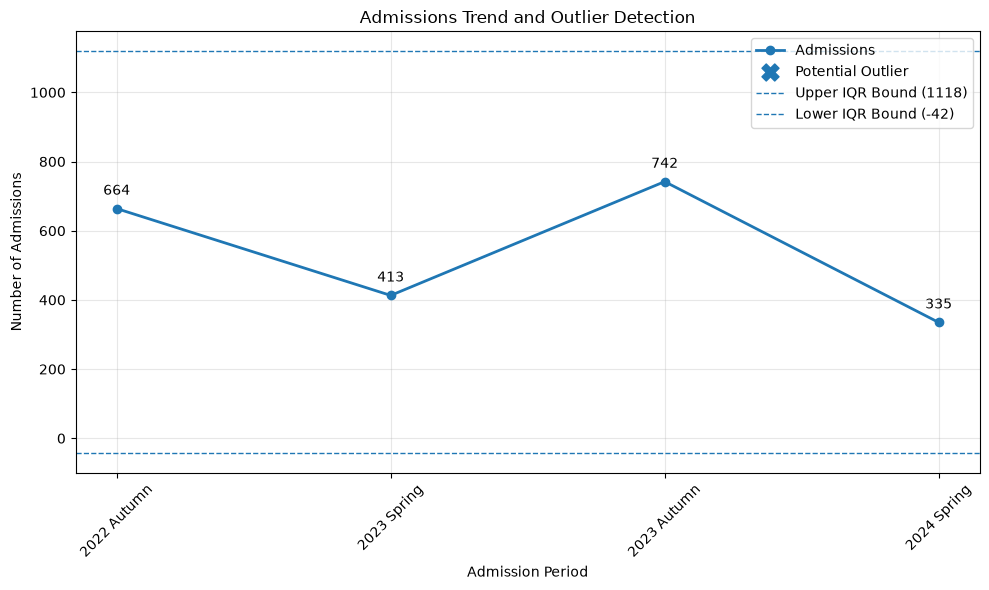

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# Create the dataset
# -----------------------------
data = {
    "Day": [2022, 2023, 2023, 2024],
    "Season": ["Autumn", "Spring", "Autumn", "Spring"],
    "Admissions": [664, 413, 742, 335]
}

df = pd.DataFrame(data)

# Create a period label
df["Period"] = df["Day"].astype(str) + " " + df["Season"]

# -----------------------------
# Calculate IQR
# -----------------------------
Q1 = df["Admissions"].quantile(0.25)
Q3 = df["Admissions"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
df["Outlier"] = (
    (df["Admissions"] < lower_bound) |
    (df["Admissions"] > upper_bound)
)

# -----------------------------
# Print results
# -----------------------------
print("IQR Analysis")
print(f"Q1: {Q1:.2f}")
print(f"Q3: {Q3:.2f}")
print(f"IQR: {IQR:.2f}")
print(f"Lower Bound: {lower_bound:.2f}")
print(f"Upper Bound: {upper_bound:.2f}")

print("\nPotential Outliers:")
print(df[df["Outlier"]])

# -----------------------------
# Plot
# -----------------------------
plt.figure(figsize=(10, 6))

# Plot admissions
plt.plot(
    df["Period"],
    df["Admissions"],
    marker="o",
    linewidth=2,
    label="Admissions"
)

# Highlight outliers
outliers = df[df["Outlier"]]

plt.scatter(
    outliers["Period"],
    outliers["Admissions"],
    s=150,
    marker="X",
    label="Potential Outlier"
)

# Add labels to every data point
for _, row in df.iterrows():
    plt.annotate(
        f'{row["Admissions"]}',
        (row["Period"], row["Admissions"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

# Add IQR boundaries
plt.axhline(
    upper_bound,
    linestyle="--",
    linewidth=1,
    label=f"Upper IQR Bound ({upper_bound:.0f})"
)

plt.axhline(
    lower_bound,
    linestyle="--",
    linewidth=1,
    label=f"Lower IQR Bound ({lower_bound:.0f})"
)

plt.title("Admissions Trend and Outlier Detection")
plt.xlabel("Admission Period")
plt.ylabel("Number of Admissions")

plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

LAD Regression Results
----------------------------------------
Intercept (β0): 773.67
Trend (β1):     -109.67

Actual vs LAD Fitted:
   Year  Season  Admissions  LAD_Fitted
0  2022  Autumn         664  664.000000
1  2023  Spring         413  554.333333
2  2023  Autumn         742  444.666667
3  2024  Spring         335  335.000000

Next Period Forecast
----------------------------------------
Forecasted Admissions: 225


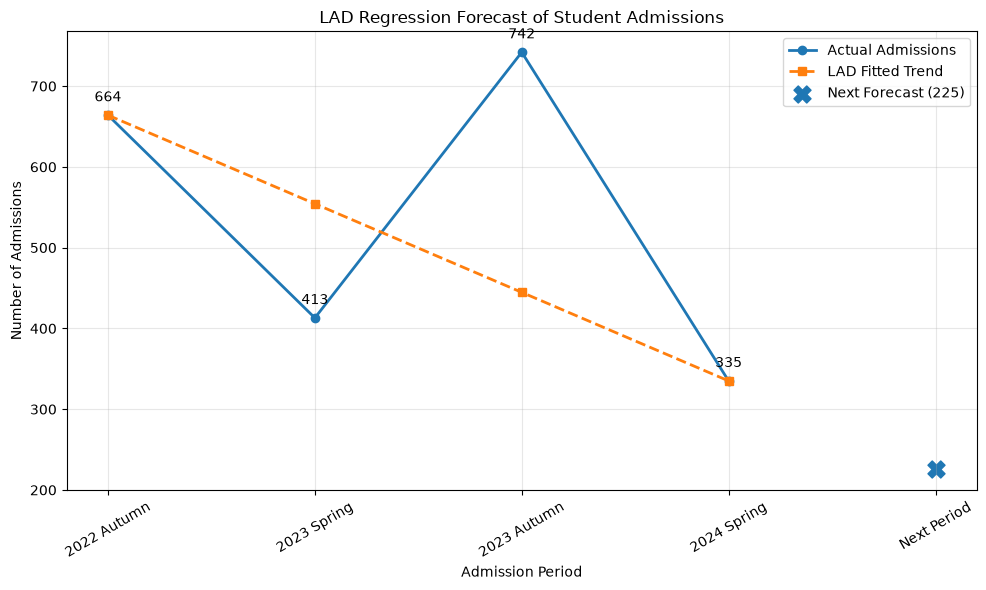

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import linprog

# ============================================================
# 1. Data
# ============================================================

df = pd.DataFrame({
    "Day": [2022, 2023, 2023, 2024],
    "Season": ["Autumn", "Spring", "Autumn", "Spring"],
    "Admissions": [664, 413, 742, 335]
})

# Create sequential time index
df["t"] = np.arange(1, len(df) + 1)

X = df["t"].values
y = df["Admissions"].values

# ============================================================
# 2. LAD Regression
#
# Minimize:
#     sum(|y - (beta0 + beta1*t)|)
#
# We transform absolute errors into:
#
#     e = e_plus - e_minus
#     |e| = e_plus + e_minus
# ============================================================

n = len(df)

# Decision variables:
# [beta0, beta1, e1_plus, ..., en_plus,
#                e1_minus, ..., en_minus]

c = np.concatenate([
    [0, 0],
    np.ones(n),
    np.ones(n)
])

# Equality constraints
A_eq = np.zeros((n, 2 + 2*n))
b_eq = y.copy()

for i in range(n):
    # y_i = beta0 + beta1*t_i + e_plus - e_minus
    A_eq[i, 0] = 1
    A_eq[i, 1] = X[i]
    A_eq[i, 2 + i] = 1
    A_eq[i, 2 + n + i] = -1

# Bounds:
# beta0 and beta1 unrestricted
# error variables >= 0
bounds = [
    (None, None),  # beta0
    (None, None)   # beta1
] + [(0, None)] * (2*n)

# Solve LAD optimization
result = linprog(
    c,
    A_eq=A_eq,
    b_eq=b_eq,
    bounds=bounds,
    method="highs"
)

# Extract coefficients
beta0 = result.x[0]
beta1 = result.x[1]

print("LAD Regression Results")
print("-" * 40)
print(f"Intercept (β0): {beta0:.2f}")
print(f"Trend (β1):     {beta1:.2f}")

# ============================================================
# 3. Fitted values
# ============================================================

df["LAD_Fitted"] = beta0 + beta1 * df["t"]

print("\nActual vs LAD Fitted:")
print(df[["Day", "Season", "Admissions", "LAD_Fitted"]])

# ============================================================
# 4. Forecast next admission period
# ============================================================

next_t = len(df) + 1

forecast = beta0 + beta1 * next_t

print("\nNext Period Forecast")
print("-" * 40)
print(f"Forecasted Admissions: {forecast:.0f}")

# ============================================================
# 5. Plot Actual vs LAD Forecast
# ============================================================

plt.figure(figsize=(10, 6))

# Actual values
plt.plot(
    df["t"],
    df["Admissions"],
    marker="o",
    linewidth=2,
    label="Actual Admissions"
)

# LAD fitted values
plt.plot(
    df["t"],
    df["LAD_Fitted"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="LAD Fitted Trend"
)

# Next-period forecast
plt.scatter(
    next_t,
    forecast,
    marker="X",
    s=150,
    label=f"Next Forecast ({forecast:.0f})"
)

# Add labels
for _, row in df.iterrows():
    plt.annotate(
        f'{row["Admissions"]}',
        (row["t"], row["Admissions"]),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

# X-axis labels
period_labels = df["Day"].astype(str) + " " + df["Season"]
all_labels = list(period_labels) + ["Next Period"]

plt.xticks(
    range(1, next_t + 1),
    all_labels,
    rotation=30
)

plt.title("LAD Regression Forecast of Student Admissions")
plt.xlabel("Admission Period")
plt.ylabel("Number of Admissions")

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Historical Data
        Period  Admissions
0  2022 Autumn         664
1  2023 Spring         413
2  2023 Autumn         742
3  2024 Spring         335

Seasonal Naive Forecast
    Day  Season       Period  Seasonal_Naive_Forecast
0  2024  Autumn  2024 Autumn                      664
1  2025  Spring  2025 Spring                      413

Seasonal Changes
Autumn change: 78
Spring change: -78

Seasonal Trend Forecast
    Day  Season       Period  Seasonal_Naive_Forecast  Seasonal_Trend_Forecast
0  2024  Autumn  2024 Autumn                      664                      820
1  2025  Spring  2025 Spring                      413                      257


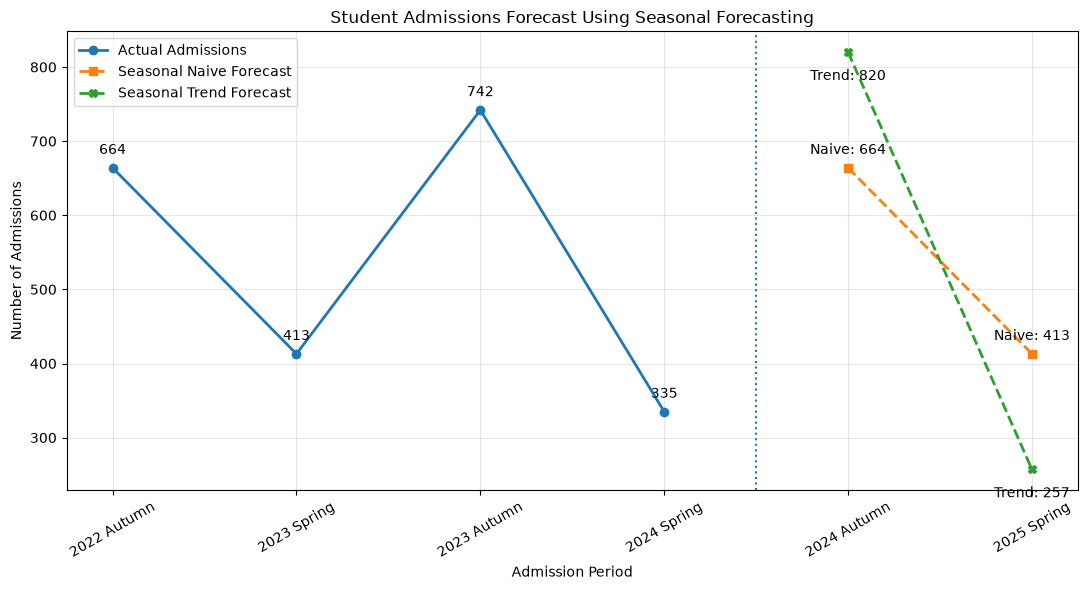


FINAL FORECAST
2024 Autumn: Seasonal Naive = 664, Seasonal Trend = 820
2025 Spring: Seasonal Naive = 413, Seasonal Trend = 257


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1. DATA
# ============================================================

df = pd.DataFrame({
    "Day": [2022, 2023, 2023, 2024],
    "Season": ["Autumn", "Spring", "Autumn", "Spring"],
    "Admissions": [664, 413, 742, 335]
})

# Sort chronologically
season_order = {"Spring": 0, "Autumn": 1}

df["Season_Order"] = df["Season"].map(season_order)

df = df.sort_values(
    ["Day", "Season_Order"]
).reset_index(drop=True)

# Create period index
df["Period"] = (
    df["Day"].astype(str)
    + " "
    + df["Season"]
)

print("Historical Data")
print(df[["Period", "Admissions"]])


# ============================================================
# 2. SEASONAL NAIVE FORECAST
# ============================================================

# Two seasons per Day
season_length = 2

# Forecast next two periods
future = pd.DataFrame({
    "Day": [2024, 2025],
    "Season": ["Autumn", "Spring"]
})

future["Period"] = (
    future["Day"].astype(str)
    + " "
    + future["Season"]
)

# Seasonal naive forecast:
# Autumn forecast = previous Autumn
# Spring forecast = previous Spring

future["Seasonal_Naive_Forecast"] = [
    df.loc[
        (df["Day"] == 2022) &
        (df["Season"] == "Autumn"),
        "Admissions"
    ].iloc[0],

    df.loc[
        (df["Day"] == 2023) &
        (df["Season"] == "Spring"),
        "Admissions"
    ].iloc[0]
]

print("\nSeasonal Naive Forecast")
print(future)


# ============================================================
# 3. SEASONAL TREND ADJUSTMENT
# ============================================================

# Calculate average Day-to-Day change
# for each season

autumn_change = 742 - 664
spring_change = 335 - 413

print("\nSeasonal Changes")
print("Autumn change:", autumn_change)
print("Spring change:", spring_change)

# Forecast next Autumn
autumn_forecast = 742 + autumn_change

# Forecast next Spring
spring_forecast = 335 + spring_change

future["Seasonal_Trend_Forecast"] = [
    autumn_forecast,
    spring_forecast
]

print("\nSeasonal Trend Forecast")
print(future)


# ============================================================
# 4. PLOT
# ============================================================

historical_periods = df["Period"].tolist()

forecast_periods = future["Period"].tolist()

all_periods = historical_periods + forecast_periods

historical_x = np.arange(len(historical_periods))

forecast_x = np.arange(
    len(historical_periods),
    len(all_periods)
)

plt.figure(figsize=(11, 6))

# ----------------------------------------
# Historical admissions
# ----------------------------------------

plt.plot(
    historical_x,
    df["Admissions"],
    marker="o",
    linewidth=2,
    label="Actual Admissions"
)

# ----------------------------------------
# Seasonal Naive forecast
# ----------------------------------------

plt.plot(
    forecast_x,
    future["Seasonal_Naive_Forecast"],
    marker="s",
    linestyle="--",
    linewidth=2,
    label="Seasonal Naive Forecast"
)

# ----------------------------------------
# Seasonal Trend forecast
# ----------------------------------------

plt.plot(
    forecast_x,
    future["Seasonal_Trend_Forecast"],
    marker="X",
    linestyle="--",
    linewidth=2,
    label="Seasonal Trend Forecast"
)

# ----------------------------------------
# Add value labels
# ----------------------------------------

for i, value in enumerate(df["Admissions"]):

    plt.annotate(
        str(value),
        (historical_x[i], value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

for i, value in enumerate(
    future["Seasonal_Naive_Forecast"]
):

    plt.annotate(
        f"Naive: {value}",
        (forecast_x[i], value),
        xytext=(0, 10),
        textcoords="offset points",
        ha="center"
    )

for i, value in enumerate(
    future["Seasonal_Trend_Forecast"]
):

    plt.annotate(
        f"Trend: {value}",
        (forecast_x[i], value),
        xytext=(0, -20),
        textcoords="offset points",
        ha="center"
    )


# ----------------------------------------
# Formatting
# ----------------------------------------

plt.xticks(
    range(len(all_periods)),
    all_periods,
    rotation=30
)

plt.axvline(
    x=len(historical_periods) - 0.5,
    linestyle=":",
    linewidth=1.5
)

plt.title(
    "Student Admissions Forecast "
    "Using Seasonal Forecasting"
)

plt.xlabel("Admission Period")

plt.ylabel("Number of Admissions")

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 5. FINAL FORECAST
# ============================================================

print("\n" + "=" * 50)
print("FINAL FORECAST")
print("=" * 50)

for _, row in future.iterrows():

    print(
        f"{row['Period']}: "
        f"Seasonal Naive = "
        f"{row['Seasonal_Naive_Forecast']:.0f}, "
        f"Seasonal Trend = "
        f"{row['Seasonal_Trend_Forecast']:.0f}"
    )

In [13]:
%pip install statsmodels

   ---------------------------------------- 0.0/9.6 MB ? eta -:--:--
   -------- ------------------------------- 2.1/9.6 MB 13.9 MB/s eta 0:00:01
   ------------------ --------------------- 4.5/9.6 MB 12.6 MB/s eta 0:00:01
   ---------------------------- ----------- 6.8/9.6 MB 12.1 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.6 MB 12.4 MB/s eta 0:00:01
   ---------------------------------------- 9.6/9.6 MB 12.1 MB/s  0:00:00

   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   ---------------------------------------- 0/2 [patsy]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -------------------- ------------------- 1/2 [statsmodels]
   -----


MODEL COMPARISON
         Model           MSE       RMSE
Seasonal Naive   6084.000000  78.000000
          Holt 115137.357440 339.318961
         Naive 136945.000000 370.060806
  Linear Trend 229216.888889 478.766006

BEST MODEL: Seasonal Naive

BASE FORECAST
[742. 335.]

Historical Forecast Errors:
[ 78. -78.]

SIMULATED FORECAST
     Period  Base Forecast  P10 Low  P50 Expected  P90 High
2024 Autumn          742.0    664.0         742.0     820.0
2025 Spring          335.0    257.0         413.0     413.0


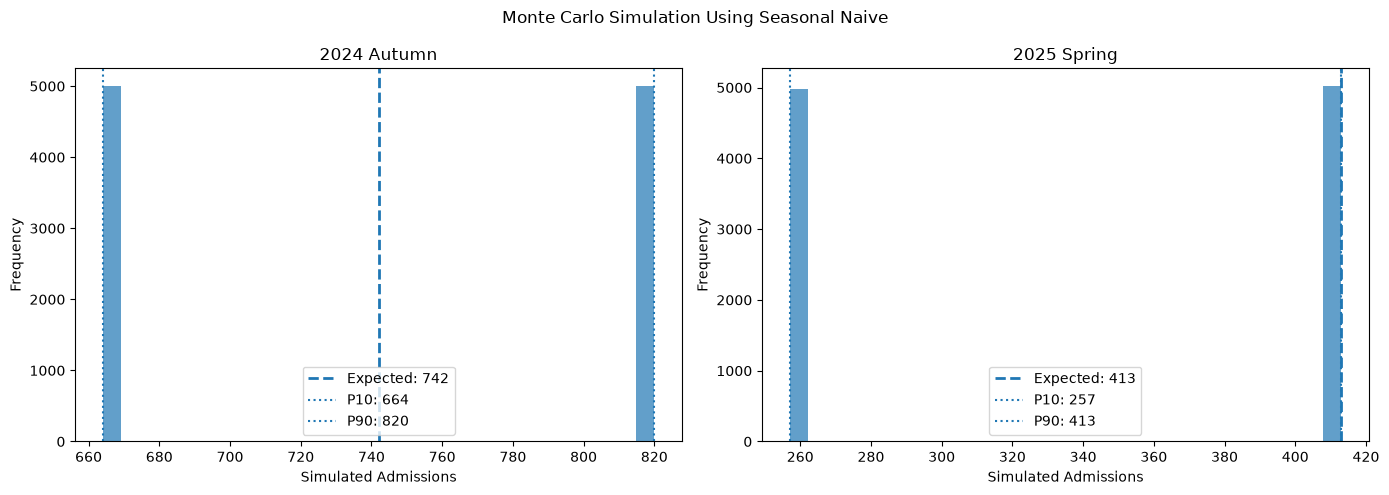

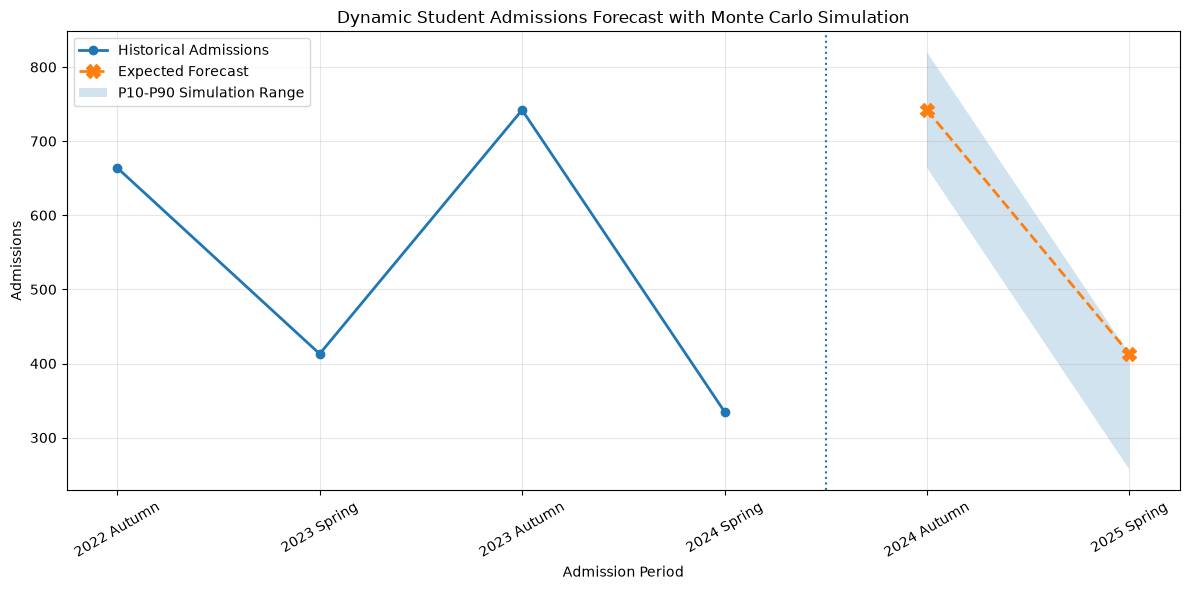

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import Holt

# ============================================================
# 1. DATA
# ============================================================

df = pd.DataFrame({
    "Year": [2022, 2023, 2023, 2024],
    "Season": ["Autumn", "Spring", "Autumn", "Spring"],
    "Admissions": [664, 413, 742, 335]
})

# Chronological ordering
season_order = {
    "Spring": 0,
    "Autumn": 1
}

df["Season_Order"] = df["Season"].map(season_order)

df = df.sort_values(
    ["Year", "Season_Order"]
).reset_index(drop=True)

df["Period"] = (
    df["Year"].astype(str)
    + " "
    + df["Season"]
)

y = df["Admissions"].values.astype(float)


# ============================================================
# 2. FORECASTING MODELS
# ============================================================

def naive(train, horizon):

    return np.repeat(
        train[-1],
        horizon
    )


def seasonal_naive(
    train,
    horizon,
    season_length=2
):

    if len(train) < season_length:

        return naive(
            train,
            horizon
        )

    forecasts = []

    for i in range(horizon):

        index = (
            len(train)
            - season_length
            + i
        )

        if index < len(train):

            forecasts.append(
                train[index]
            )

        else:

            forecasts.append(
                forecasts[
                    i - season_length
                ]
            )

    return np.array(
        forecasts
    )


def linear_trend(
    train,
    horizon
):

    x = np.arange(
        len(train)
    )

    coefficients = np.polyfit(
        x,
        train,
        1
    )

    future_x = np.arange(
        len(train),
        len(train)
        + horizon
    )

    return np.polyval(
        coefficients,
        future_x
    )


def holt(
    train,
    horizon
):

    if len(train) < 3:

        return naive(
            train,
            horizon
        )

    model = Holt(
        train,
        initialization_method="estimated"
    )

    fitted = model.fit(
        optimized=True
    )

    return fitted.forecast(
        horizon
    )


models = {

    "Naive":
        naive,

    "Seasonal Naive":
        seasonal_naive,

    "Linear Trend":
        linear_trend,

    "Holt":
        holt

}


# ============================================================
# 3. ROLLING-ORIGIN MSE
# ============================================================

def rolling_mse(
    model_function,
    data,
    min_train=2
):

    actual = []

    predicted = []

    for t in range(
        min_train,
        len(data)
    ):

        train = data[:t]

        test = data[t]

        try:

            forecast = model_function(
                train,
                1
            )[0]

            actual.append(
                test
            )

            predicted.append(
                forecast
            )

        except:

            continue

    if len(actual) == 0:

        return np.inf

    return mean_squared_error(
        actual,
        predicted
    )


# ============================================================
# 4. SELECT BEST MODEL
# ============================================================

model_results = []

for name, model in models.items():

    mse = rolling_mse(
        model,
        y
    )

    model_results.append({

        "Model": name,

        "MSE": mse,

        "RMSE": np.sqrt(mse)

    })


results = pd.DataFrame(
    model_results
).sort_values(
    "MSE"
).reset_index(
    drop=True
)


best_model_name = (
    results
    .iloc[0]
    ["Model"]
)

best_model = models[
    best_model_name
]


print("\nMODEL COMPARISON")
print("=" * 50)

print(
    results.to_string(
        index=False
    )
)

print(
    "\nBEST MODEL:",
    best_model_name
)


# ============================================================
# 5. FIT BEST MODEL
# ============================================================

forecast_horizon = 2

base_forecast = best_model(
    y,
    forecast_horizon
)

print("\nBASE FORECAST")
print("=" * 50)

print(
    base_forecast
)


# ============================================================
# 6. ESTIMATE HISTORICAL FORECAST ERRORS
# ============================================================

errors = []

min_train = 2

for t in range(
    min_train,
    len(y)
):

    train = y[:t]

    actual = y[t]

    forecast = best_model(
        train,
        1
    )[0]

    error = (
        actual
        - forecast
    )

    errors.append(
        error
    )


errors = np.array(
    errors
)


print(
    "\nHistorical Forecast Errors:"
)

print(
    errors
)


# ============================================================
# 7. MONTE CARLO SIMULATION
# ============================================================

np.random.seed(42)

n_simulations = 10000

simulated_forecasts = np.zeros(
    (
        n_simulations,
        forecast_horizon
    )
)


for simulation in range(
    n_simulations
):

    # Randomly sample historical errors
    sampled_errors = np.random.choice(
        errors,
        size=forecast_horizon,
        replace=True
    )

    simulated_forecasts[
        simulation
    ] = (

        base_forecast

        + sampled_errors

    )


# ============================================================
# 8. FORECAST DISTRIBUTION
# ============================================================

p10 = np.percentile(
    simulated_forecasts,
    10,
    axis=0
)

p50 = np.percentile(
    simulated_forecasts,
    50,
    axis=0
)

p90 = np.percentile(
    simulated_forecasts,
    90,
    axis=0
)


# ============================================================
# 9. FUTURE PERIODS
# ============================================================

future_periods = [
    "2024 Autumn",
    "2025 Spring"
]


forecast_results = pd.DataFrame({

    "Period":
        future_periods,

    "Base Forecast":
        np.round(
            base_forecast
        ),

    "P10 Low":
        np.round(
            p10
        ),

    "P50 Expected":
        np.round(
            p50
        ),

    "P90 High":
        np.round(
            p90
        )

})


print(
    "\nSIMULATED FORECAST"
)

print("=" * 70)

print(
    forecast_results.to_string(
        index=False
    )
)


# ============================================================
# 10. PLOT SIMULATED FORECAST DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(
    1,
    forecast_horizon,
    figsize=(14, 5)
)


for i in range(
    forecast_horizon
):

    axes[i].hist(

        simulated_forecasts[:, i],

        bins=30,

        alpha=0.7

    )

    axes[i].axvline(

        p50[i],

        linestyle="--",

        linewidth=2,

        label=(
            f"Expected: "
            f"{p50[i]:.0f}"
        )

    )

    axes[i].axvline(

        p10[i],

        linestyle=":",

        label=(
            f"P10: "
            f"{p10[i]:.0f}"
        )

    )

    axes[i].axvline(

        p90[i],

        linestyle=":",

        label=(
            f"P90: "
            f"{p90[i]:.0f}"
        )

    )

    axes[i].set_title(
        future_periods[i]
    )

    axes[i].set_xlabel(
        "Simulated Admissions"
    )

    axes[i].set_ylabel(
        "Frequency"
    )

    axes[i].legend()


plt.suptitle(

    f"Monte Carlo Simulation "
    f"Using {best_model_name}"

)

plt.tight_layout()

plt.show()


# ============================================================
# 11. HISTORICAL + FORECAST PLOT
# ============================================================

plt.figure(
    figsize=(12, 6)
)


historical_x = np.arange(
    len(y)
)

future_x = np.arange(
    len(y),
    len(y)
    + forecast_horizon
)


# Historical
plt.plot(

    historical_x,

    y,

    marker="o",

    linewidth=2,

    label="Historical Admissions"

)


# Expected forecast
plt.plot(

    future_x,

    p50,

    marker="X",

    markersize=10,

    linestyle="--",

    linewidth=2,

    label="Expected Forecast"

)


# Prediction interval
plt.fill_between(

    future_x,

    p10,

    p90,

    alpha=0.2,

    label="P10-P90 Simulation Range"

)


# Labels
all_periods = (

    df["Period"].tolist()

    + future_periods

)


plt.xticks(

    range(
        len(all_periods)
    ),

    all_periods,

    rotation=30

)


plt.axvline(

    len(y) - 0.5,

    linestyle=":",

    linewidth=1.5

)


plt.title(

    "Dynamic Student Admissions Forecast "
    "with Monte Carlo Simulation"

)


plt.xlabel(
    "Admission Period"
)

plt.ylabel(
    "Admissions"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()

ValueError: All arrays must be of the same length


MODEL PERFORMANCE
                Model       MSE     RMSE
Exponential Smoothing 15.210187 3.900024
           Holt Trend 18.120771 4.256850
       Moving Average 19.087719 4.368949
                Naive 28.210526 5.311358

BEST MODEL:
Exponential Smoothing

7-DAY FORECAST
 Day  Forecast Admissions
  25                    7
  26                    7
  27                    7
  28                    7
  29                    7
  30                    7
  31                    7


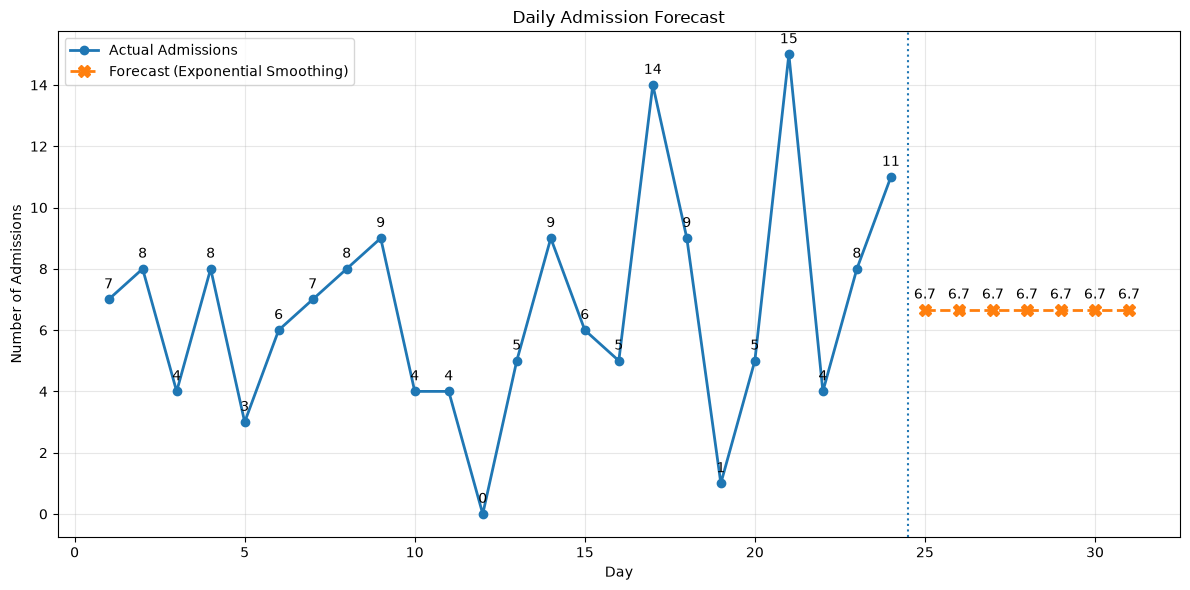

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt
)


# ============================================================
# 1. DATA
# ============================================================

df = pd.DataFrame({
    "Day": list(range(1, 25)),
    "Admissions": [
        7, 8, 4, 8, 3, 6,
        7, 8, 9, 4, 4, 0,
        5, 9, 6, 5, 14, 9,
        1, 5, 15, 4, 8, 11
    ]
})

y = df["Admissions"].values.astype(float)


# ============================================================
# 2. FORECASTING MODELS
# ============================================================

def naive_forecast(train, horizon):

    return np.repeat(
        train[-1],
        horizon
    )


def moving_average_forecast(
    train,
    horizon,
    window=3
):

    forecast = []

    history = list(train)

    for _ in range(horizon):

        prediction = np.mean(
            history[-window:]
        )

        forecast.append(
            prediction
        )

        history.append(
            prediction
        )

    return np.array(
        forecast
    )


def exponential_smoothing_forecast(
    train,
    horizon
):

    if len(train) < 2:

        return naive_forecast(
            train,
            horizon
        )

    model = SimpleExpSmoothing(
        train,
        initialization_method="estimated"
    )

    fitted_model = model.fit(
        optimized=True
    )

    return fitted_model.forecast(
        horizon
    )


def holt_forecast(
    train,
    horizon
):

    if len(train) < 3:

        return naive_forecast(
            train,
            horizon
        )

    model = Holt(
        train,
        initialization_method="estimated"
    )

    fitted_model = model.fit(
        optimized=True
    )

    return fitted_model.forecast(
        horizon
    )


# ============================================================
# 3. MODEL LIST
# ============================================================

models = {

    "Naive":
        naive_forecast,

    "Moving Average":
        moving_average_forecast,

    "Exponential Smoothing":
        exponential_smoothing_forecast,

    "Holt Trend":
        holt_forecast

}


# ============================================================
# 4. ROLLING-ORIGIN VALIDATION
# ============================================================

def evaluate_model(
    model_function,
    data,
    min_train_size=5
):

    actuals = []

    predictions = []

    for t in range(
        min_train_size,
        len(data)
    ):

        train = data[:t]

        actual = data[t]

        try:

            prediction = model_function(
                train,
                1
            )[0]

            actuals.append(
                actual
            )

            predictions.append(
                prediction
            )

        except Exception:

            continue

    if len(actuals) == 0:

        return np.inf

    mse = mean_squared_error(
        actuals,
        predictions
    )

    return mse


# ============================================================
# 5. MODEL COMPARISON
# ============================================================

results = []

for name, model in models.items():

    mse = evaluate_model(
        model,
        y
    )

    results.append({

        "Model":
            name,

        "MSE":
            mse,

        "RMSE":
            np.sqrt(mse)

    })


results_df = pd.DataFrame(
    results
)

results_df = results_df.sort_values(
    "MSE"
).reset_index(
    drop=True
)


# ============================================================
# 6. SELECT BEST MODEL
# ============================================================

best_model_name = (
    results_df
    .iloc[0]
    ["Model"]
)

best_model = models[
    best_model_name
]


print("\nMODEL PERFORMANCE")
print("=" * 50)

print(
    results_df.to_string(
        index=False
    )
)

print(
    "\nBEST MODEL:"
)

print(
    best_model_name
)


# ============================================================
# 7. FORECAST NEXT 7 DAYS
# ============================================================

forecast_horizon = 7

forecast = best_model(
    y,
    forecast_horizon
)


# Admissions cannot be negative
forecast = np.maximum(
    forecast,
    0
)


future_days = np.arange(
    25,
    32
)


forecast_df = pd.DataFrame({

    "Day":
        future_days,

    "Forecast Admissions":
        np.round(
            forecast
        ).astype(int)

})


print("\n7-DAY FORECAST")
print("=" * 50)

print(
    forecast_df.to_string(
        index=False
    )
)


# ============================================================
# 8. PLOT
# ============================================================

plt.figure(
    figsize=(12, 6)
)


# Historical admissions

plt.plot(

    df["Day"],

    df["Admissions"],

    marker="o",

    linewidth=2,

    label="Actual Admissions"

)


# Forecast

plt.plot(

    future_days,

    forecast,

    marker="X",

    markersize=9,

    linestyle="--",

    linewidth=2,

    label=(
        f"Forecast "
        f"({best_model_name})"
    )

)


# Add historical labels

for _, row in df.iterrows():

    plt.annotate(

        str(
            int(
                row["Admissions"]
            )
        ),

        (
            row["Day"],
            row["Admissions"]
        ),

        xytext=(0, 8),

        textcoords=(
            "offset points"
        ),

        ha="center"

    )


# Add forecast labels

for day, value in zip(
    future_days,
    forecast
):

    plt.annotate(

        f"{value:.1f}",

        (
            day,
            value
        ),

        xytext=(0, 8),

        textcoords=(
            "offset points"
        ),

        ha="center"

    )


# Separate historical and forecast

plt.axvline(

    x=24.5,

    linestyle=":",

    linewidth=1.5

)


plt.title(

    "Daily Admission Forecast"

)


plt.xlabel(

    "Day"

)


plt.ylabel(

    "Number of Admissions"

)


plt.legend()


plt.grid(

    True,

    alpha=0.3

)


plt.tight_layout()


plt.show()


MODEL COMPARISON
                Model       MSE     RMSE
Exponential Smoothing 15.210187 3.900024
           Holt Trend 18.120771 4.256850
       Moving Average 19.087719 4.368949
                Naive 28.210526 5.311358

BEST MODEL: Exponential Smoothing

HISTORICAL FORECAST ERRORS
[ 8.71942456e-08  1.00000002e+00  1.85714288e+00  2.62500005e+00
 -2.66666663e+00 -2.39999996e+00 -6.18181816e+00 -6.66666664e-01
  3.38461539e+00  1.42857120e-01 -8.66666623e-01  8.18749998e+00
  2.70588229e+00 -5.44444445e+00 -1.15789484e+00  8.89999997e+00
 -2.52380951e+00  1.59090911e+00  4.52173917e+00]

SIMULATED FORECAST
 Day  Base Forecast  P10  P25  Expected P50  P75  P90
  25            6.7  4.0  4.3           6.8  9.4 14.9
  26            6.7  1.2  4.3           6.8  9.4 14.9
  27            6.7  1.2  4.3           6.8  9.4 14.9
  28            6.7  1.2  4.3           6.8  9.4 14.9
  29            6.7  1.2  4.3           6.8  9.4 11.2
  30            6.7  1.2  4.3           6.8  9.4 14.9
  31  

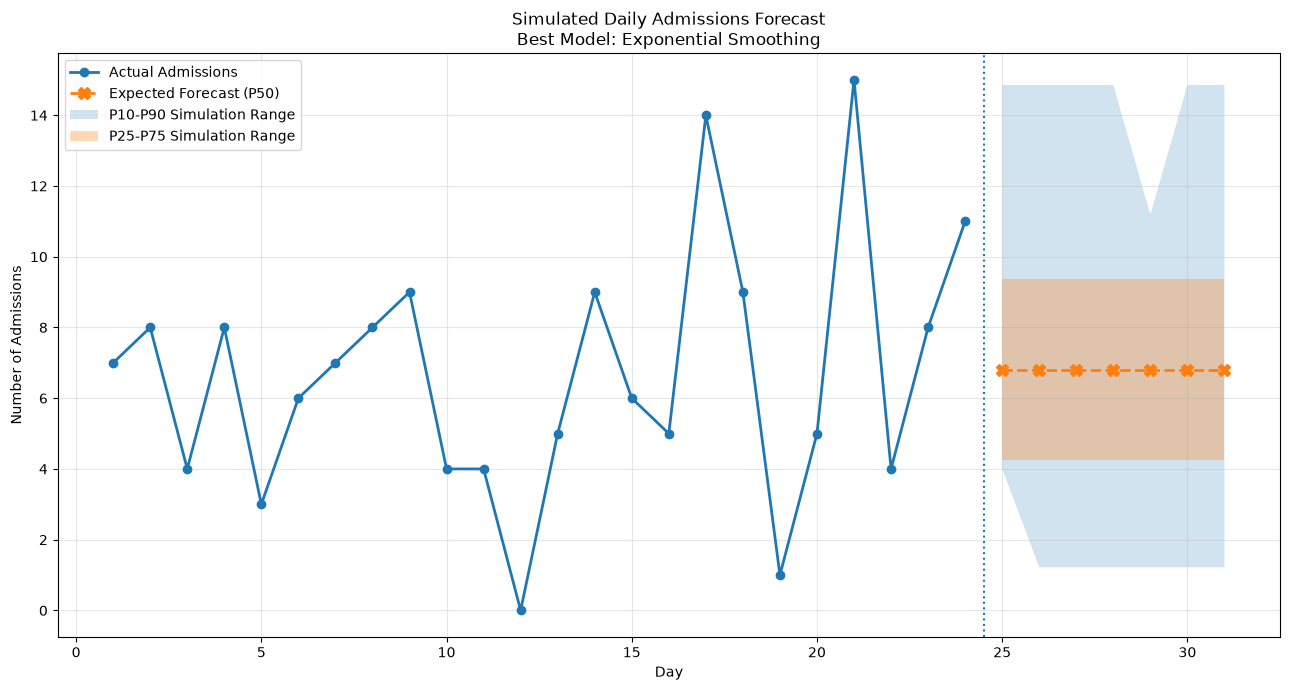

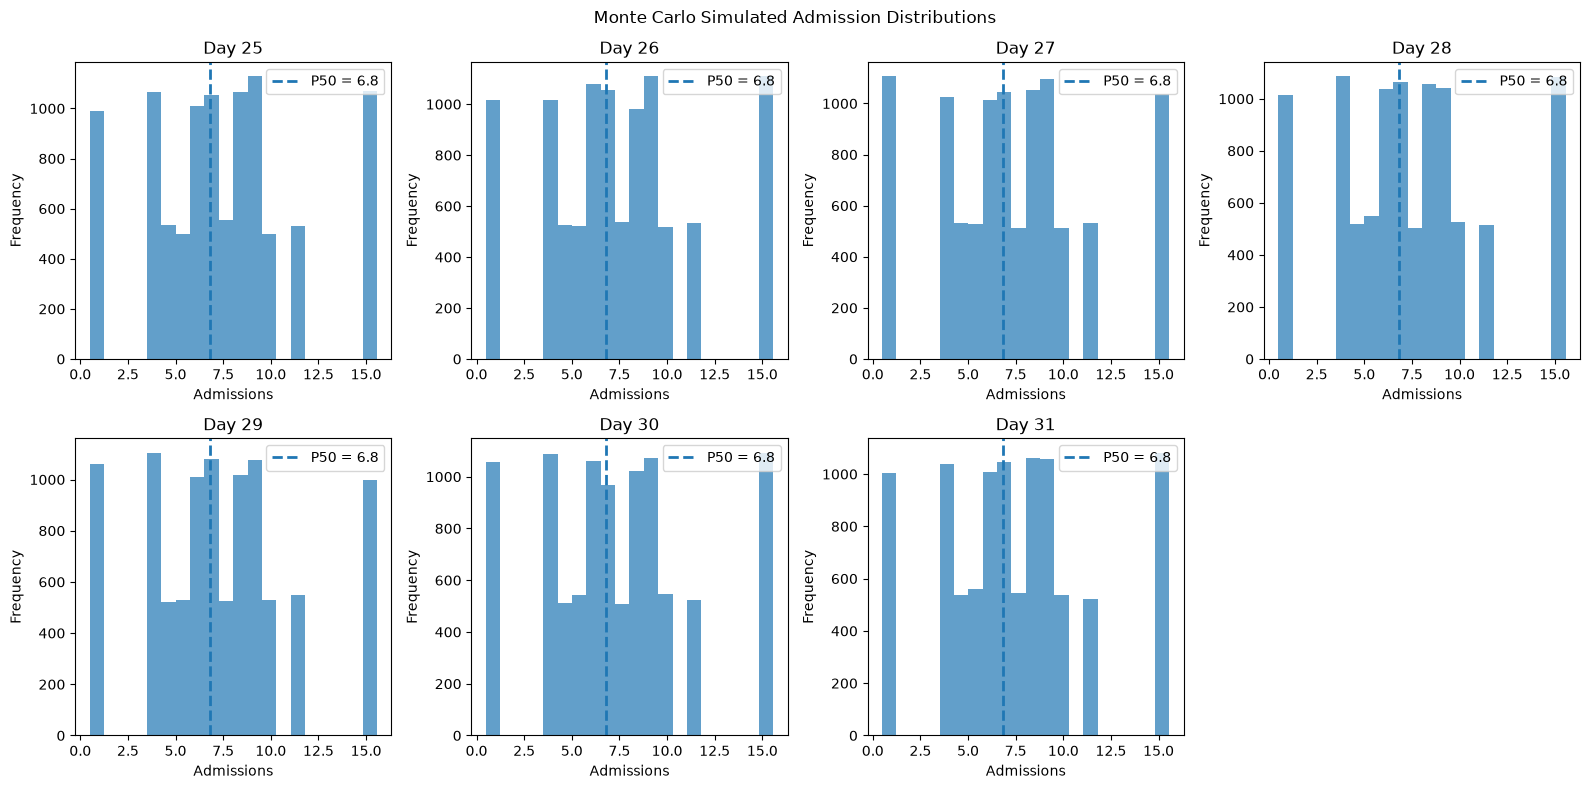

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt
)

# ============================================================
# 1. DATA
# ============================================================

df = pd.DataFrame({
    "Day": np.arange(1, 25),
    "Admissions": [
        7, 8, 4, 8, 3, 6,
        7, 8, 9, 4, 4, 0,
        5, 9, 6, 5, 14, 9,
        1, 5, 15, 4, 8, 11
    ]
})

y = df["Admissions"].values.astype(float)


# ============================================================
# 2. FORECASTING MODELS
# ============================================================

def naive_forecast(train, horizon):

    return np.repeat(
        train[-1],
        horizon
    )


def moving_average_forecast(
    train,
    horizon,
    window=3
):

    history = list(train)

    forecasts = []

    for _ in range(horizon):

        prediction = np.mean(
            history[-window:]
        )

        forecasts.append(
            prediction
        )

        history.append(
            prediction
        )

    return np.array(
        forecasts
    )


def exponential_smoothing_forecast(
    train,
    horizon
):

    model = SimpleExpSmoothing(
        train,
        initialization_method="estimated"
    )

    fitted_model = model.fit(
        optimized=True
    )

    return fitted_model.forecast(
        horizon
    )


def holt_forecast(
    train,
    horizon
):

    model = Holt(
        train,
        initialization_method="estimated"
    )

    fitted_model = model.fit(
        optimized=True
    )

    return fitted_model.forecast(
        horizon
    )


models = {

    "Naive":
        naive_forecast,

    "Moving Average":
        moving_average_forecast,

    "Exponential Smoothing":
        exponential_smoothing_forecast,

    "Holt Trend":
        holt_forecast

}


# ============================================================
# 3. ROLLING-ORIGIN MSE
# ============================================================

def evaluate_model(
    model_function,
    data,
    min_train_size=5
):

    actuals = []

    predictions = []

    for t in range(
        min_train_size,
        len(data)
    ):

        train = data[:t]

        actual = data[t]

        try:

            prediction = model_function(
                train,
                1
            )[0]

            actuals.append(
                actual
            )

            predictions.append(
                prediction
            )

        except:

            continue

    mse = mean_squared_error(
        actuals,
        predictions
    )

    return mse


# ============================================================
# 4. SELECT BEST MODEL
# ============================================================

model_results = []

for name, model in models.items():

    mse = evaluate_model(
        model,
        y
    )

    model_results.append({

        "Model":
            name,

        "MSE":
            mse,

        "RMSE":
            np.sqrt(mse)

    })


results = pd.DataFrame(
    model_results
)

results = results.sort_values(
    "MSE"
).reset_index(
    drop=True
)


best_model_name = (
    results
    .iloc[0]
    ["Model"]
)

best_model = models[
    best_model_name
]


print("\nMODEL COMPARISON")
print("=" * 50)

print(
    results.to_string(
        index=False
    )
)

print(
    "\nBEST MODEL:",
    best_model_name
)


# ============================================================
# 5. GENERATE BASE FORECAST
# ============================================================

forecast_horizon = 7

base_forecast = best_model(
    y,
    forecast_horizon
)

# No negative admissions
base_forecast = np.maximum(
    base_forecast,
    0
)


# ============================================================
# 6. CALCULATE HISTORICAL OUT-OF-SAMPLE ERRORS
# ============================================================

historical_errors = []

min_train_size = 5

for t in range(
    min_train_size,
    len(y)
):

    train = y[:t]

    actual = y[t]

    predicted = best_model(
        train,
        1
    )[0]

    error = (
        actual
        - predicted
    )

    historical_errors.append(
        error
    )


historical_errors = np.array(
    historical_errors
)


print(
    "\nHISTORICAL FORECAST ERRORS"
)

print(
    historical_errors
)


# ============================================================
# 7. MONTE CARLO SIMULATION
# ============================================================

np.random.seed(42)

n_simulations = 10000

simulated_forecasts = np.zeros(
    (
        n_simulations,
        forecast_horizon
    )
)


for simulation in range(
    n_simulations
):

    # Sample historical forecast errors
    random_errors = np.random.choice(

        historical_errors,

        size=forecast_horizon,

        replace=True

    )

    # Add uncertainty to base forecast
    simulated_forecasts[
        simulation
    ] = (

        base_forecast

        + random_errors

    )


# Admissions cannot be negative

simulated_forecasts = np.maximum(
    simulated_forecasts,
    0
)


# ============================================================
# 8. CALCULATE FORECAST DISTRIBUTION
# ============================================================

p10 = np.percentile(

    simulated_forecasts,

    10,

    axis=0

)

p25 = np.percentile(

    simulated_forecasts,

    25,

    axis=0

)

p50 = np.percentile(

    simulated_forecasts,

    50,

    axis=0

)

p75 = np.percentile(

    simulated_forecasts,

    75,

    axis=0

)

p90 = np.percentile(

    simulated_forecasts,

    90,

    axis=0

)


# ============================================================
# 9. CREATE FORECAST TABLE
# ============================================================

future_days = np.arange(
    25,
    32
)


forecast_df = pd.DataFrame({

    "Day":
        future_days,

    "Base Forecast":
        np.round(
            base_forecast,
            1
        ),

    "P10":
        np.round(
            p10,
            1
        ),

    "P25":
        np.round(
            p25,
            1
        ),

    "Expected P50":
        np.round(
            p50,
            1
        ),

    "P75":
        np.round(
            p75,
            1
        ),

    "P90":
        np.round(
            p90,
            1
        )

})


print(
    "\nSIMULATED FORECAST"
)

print(
    "=" * 80
)

print(
    forecast_df.to_string(
        index=False
    )
)


# ============================================================
# 10. PLOT HISTORICAL + SIMULATED FORECAST
# ============================================================

plt.figure(
    figsize=(13, 7)
)


historical_days = df["Day"]


# Actual data

plt.plot(

    historical_days,

    y,

    marker="o",

    linewidth=2,

    label="Actual Admissions"

)


# Expected forecast

plt.plot(

    future_days,

    p50,

    marker="X",

    markersize=9,

    linestyle="--",

    linewidth=2,

    label=(
        "Expected Forecast (P50)"
    )

)


# P10-P90 uncertainty range

plt.fill_between(

    future_days,

    p10,

    p90,

    alpha=0.2,

    label="P10-P90 Simulation Range"

)


# P25-P75 uncertainty range

plt.fill_between(

    future_days,

    p25,

    p75,

    alpha=0.3,

    label="P25-P75 Simulation Range"

)


# Forecast boundary

plt.axvline(

    x=24.5,

    linestyle=":",

    linewidth=1.5

)


# Labels

plt.title(

    f"Simulated Daily Admissions Forecast\n"
    f"Best Model: {best_model_name}"

)

plt.xlabel(
    "Day"
)

plt.ylabel(
    "Number of Admissions"
)


plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 11. SIMULATION DISTRIBUTION FOR EACH FUTURE DAY
# ============================================================

fig, axes = plt.subplots(

    2,

    4,

    figsize=(16, 8)

)

axes = axes.flatten()


for i in range(
    forecast_horizon
):

    axes[i].hist(

        simulated_forecasts[:, i],

        bins=20,

        alpha=0.7

    )

    axes[i].axvline(

        p50[i],

        linestyle="--",

        linewidth=2,

        label=(
            f"P50 = "
            f"{p50[i]:.1f}"
        )

    )

    axes[i].set_title(

        f"Day {future_days[i]}"

    )

    axes[i].set_xlabel(

        "Admissions"

    )

    axes[i].set_ylabel(

        "Frequency"

    )

    axes[i].legend()


# Hide unused subplot

axes[-1].axis(
    "off"
)


plt.suptitle(

    "Monte Carlo Simulated Admission Distributions"

)

plt.tight_layout()

plt.show()


MODEL SELECTION
                Model       MSE     RMSE
Exponential Smoothing 15.210187 3.900024
           Holt Trend 18.120771 4.256850
       Moving Average 19.087719 4.368949
                Naive 28.210526 5.311358

Selected Best Model: Exponential Smoothing

BASE FORECAST
Day 25: 6.67 admissions
Day 26: 6.67 admissions
Day 27: 6.67 admissions
Day 28: 6.67 admissions
Day 29: 6.67 admissions
Day 30: 6.67 admissions
Day 31: 6.67 admissions

FORECAST ERRORS
[ 8.71942456e-08  1.00000002e+00  1.85714288e+00  2.62500005e+00
 -2.66666663e+00 -2.39999996e+00 -6.18181816e+00 -6.66666664e-01
  3.38461539e+00  1.42857120e-01 -8.66666623e-01  8.18749998e+00
  2.70588229e+00 -5.44444445e+00 -1.15789484e+00  8.89999997e+00
 -2.52380951e+00  1.59090911e+00  4.52173917e+00]

Error Mean: 0.6846146972728226
Error Std: 3.94467509942295

SIMULATED FORECAST
 Day  Base Forecast  P10 Low  P50 Expected  P90 High
  25           6.67     4.00          6.81     14.85
  26           6.67     1.22          

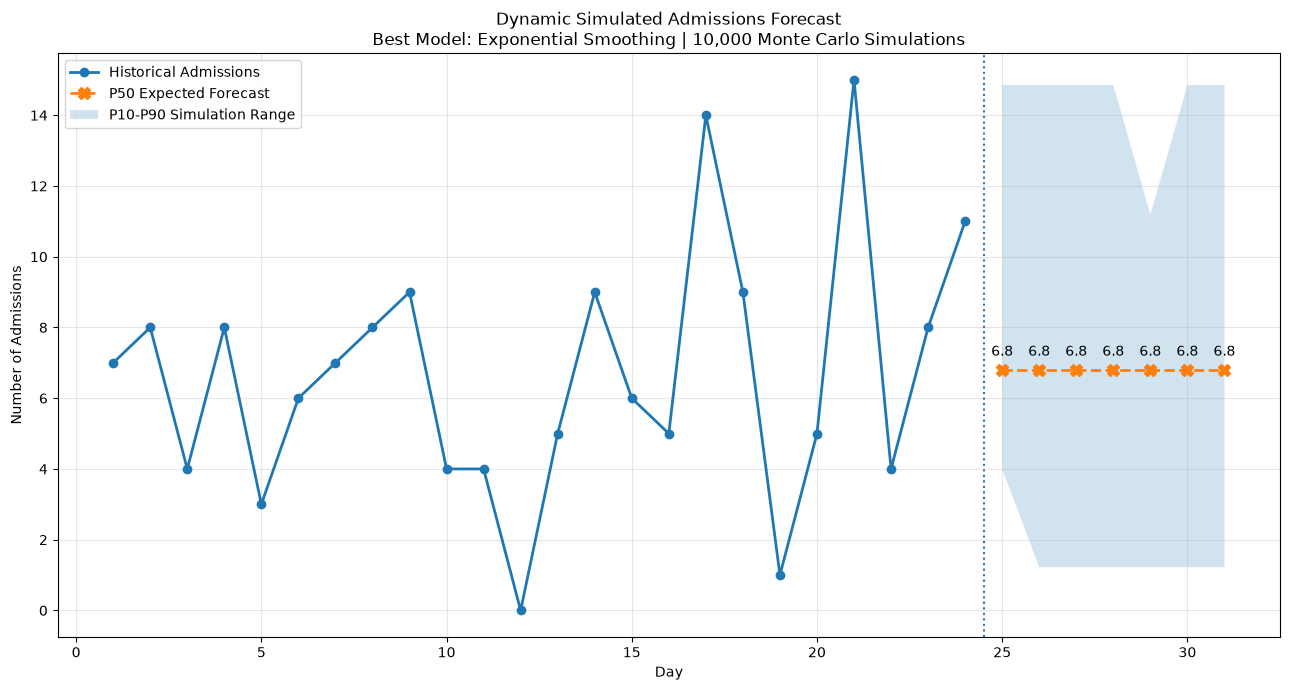


7-DAY TOTAL ADMISSIONS
P10 (Low):      39
P50 (Expected): 51
P90 (High):     65


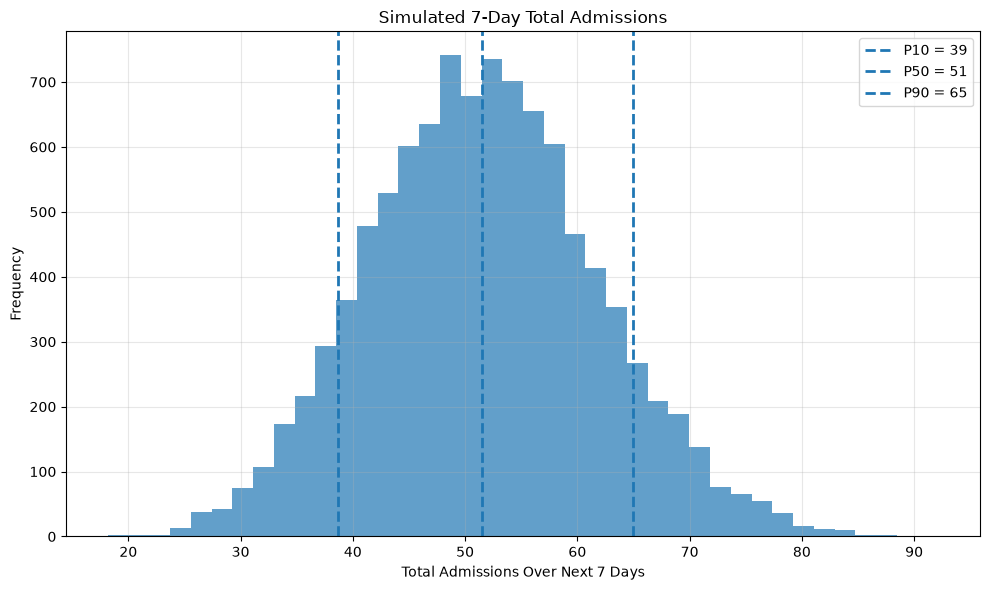

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt
)

# ============================================================
# 1. HISTORICAL ADMISSIONS
# ============================================================

df = pd.DataFrame({
    "Day": np.arange(1, 25),
    "Admissions": [
        7, 8, 4, 8, 3, 6,
        7, 8, 9, 4, 4, 0,
        5, 9, 6, 5, 14, 9,
        1, 5, 15, 4, 8, 11
    ]
})

y = df["Admissions"].astype(float).values


# ============================================================
# 2. FORECASTING MODELS
# ============================================================

# ------------------------------------------------------------
# Model 1: Naive
# ------------------------------------------------------------

def naive(train, horizon):

    return np.repeat(
        train[-1],
        horizon
    )


# ------------------------------------------------------------
# Model 2: Moving Average
# ------------------------------------------------------------

def moving_average(
    train,
    horizon,
    window=3
):

    history = list(train)

    forecasts = []

    for _ in range(horizon):

        prediction = np.mean(
            history[-window:]
        )

        forecasts.append(
            prediction
        )

        history.append(
            prediction
        )

    return np.array(
        forecasts
    )


# ------------------------------------------------------------
# Model 3: Simple Exponential Smoothing
# ------------------------------------------------------------

def exponential_smoothing(
    train,
    horizon
):

    if len(train) < 2:

        return naive(
            train,
            horizon
        )

    model = SimpleExpSmoothing(
        train,
        initialization_method="estimated"
    )

    fitted = model.fit(
        optimized=True
    )

    return fitted.forecast(
        horizon
    )


# ------------------------------------------------------------
# Model 4: Holt Linear Trend
# ------------------------------------------------------------

def holt(
    train,
    horizon
):

    if len(train) < 3:

        return naive(
            train,
            horizon
        )

    model = Holt(
        train,
        initialization_method="estimated"
    )

    fitted = model.fit(
        optimized=True
    )

    return fitted.forecast(
        horizon
    )


models = {

    "Naive":
        naive,

    "Moving Average":
        moving_average,

    "Exponential Smoothing":
        exponential_smoothing,

    "Holt Trend":
        holt

}


# ============================================================
# 3. ROLLING-ORIGIN VALIDATION
# ============================================================

def rolling_validation(
    model_function,
    data,
    min_train_size=5
):

    actuals = []

    predictions = []

    errors = []

    for t in range(
        min_train_size,
        len(data)
    ):

        train = data[:t]

        actual = data[t]

        prediction = model_function(
            train,
            1
        )[0]

        actuals.append(
            actual
        )

        predictions.append(
            prediction
        )

        errors.append(
            actual - prediction
        )

    mse = mean_squared_error(
        actuals,
        predictions
    )

    return {

        "MSE":
            mse,

        "RMSE":
            np.sqrt(mse),

        "Actual":
            np.array(actuals),

        "Prediction":
            np.array(predictions),

        "Errors":
            np.array(errors)

    }


# ============================================================
# 4. MODEL SELECTION
# ============================================================

model_results = {}

comparison = []

for name, model in models.items():

    validation = rolling_validation(
        model,
        y
    )

    model_results[name] = validation

    comparison.append({

        "Model":
            name,

        "MSE":
            validation["MSE"],

        "RMSE":
            validation["RMSE"]

    })


comparison_df = pd.DataFrame(
    comparison
).sort_values(
    "MSE"
).reset_index(
    drop=True
)


# Best model
best_model_name = (
    comparison_df
    .iloc[0]
    ["Model"]
)

best_model = models[
    best_model_name
]


print("\nMODEL SELECTION")
print("=" * 60)

print(
    comparison_df.to_string(
        index=False
    )
)

print(
    "\nSelected Best Model:",
    best_model_name
)


# ============================================================
# 5. BEST MODEL FORECAST
# ============================================================

forecast_horizon = 7

base_forecast = best_model(
    y,
    forecast_horizon
)

# Admissions cannot be negative
base_forecast = np.maximum(
    base_forecast,
    0
)


print("\nBASE FORECAST")
print("=" * 60)

for i, value in enumerate(
    base_forecast,
    start=25
):

    print(
        f"Day {i}: "
        f"{value:.2f} admissions"
    )


# ============================================================
# 6. ESTIMATE FORECAST ERRORS
# ============================================================

historical_errors = model_results[
    best_model_name
]["Errors"]


print("\nFORECAST ERRORS")
print("=" * 60)

print(
    historical_errors
)

print(
    "\nError Mean:",
    np.mean(
        historical_errors
    )
)

print(
    "Error Std:",
    np.std(
        historical_errors,
        ddof=1
    )
)


# ============================================================
# 7. MONTE CARLO SIMULATION
# ============================================================

np.random.seed(42)

n_simulations = 10_000

simulated_paths = np.zeros(
    (
        n_simulations,
        forecast_horizon
    )
)


# ------------------------------------------------------------
# Simulation method:
#
# Future Demand =
# Base Forecast + Random Historical Forecast Error
#
# Errors are sampled with replacement
# ------------------------------------------------------------

for simulation in range(
    n_simulations
):

    # Sample one error for each future day
    simulated_errors = np.random.choice(

        historical_errors,

        size=forecast_horizon,

        replace=True

    )

    simulated_paths[
        simulation
    ] = (

        base_forecast

        + simulated_errors

    )


# Prevent negative admissions
simulated_paths = np.maximum(
    simulated_paths,
    0
)


# ============================================================
# 8. CALCULATE P10 / P50 / P90
# ============================================================

p10 = np.percentile(
    simulated_paths,
    10,
    axis=0
)

p50 = np.percentile(
    simulated_paths,
    50,
    axis=0
)

p90 = np.percentile(
    simulated_paths,
    90,
    axis=0
)


# ============================================================
# 9. FINAL FORECAST TABLE
# ============================================================

future_days = np.arange(
    25,
    32
)


forecast_df = pd.DataFrame({

    "Day":
        future_days,

    "Base Forecast":
        np.round(
            base_forecast,
            2
        ),

    "P10 Low":
        np.round(
            p10,
            2
        ),

    "P50 Expected":
        np.round(
            p50,
            2
        ),

    "P90 High":
        np.round(
            p90,
            2
        )

})


print("\nSIMULATED FORECAST")
print("=" * 80)

print(
    forecast_df.to_string(
        index=False
    )
)


# ============================================================
# 10. HISTORICAL + SIMULATED FORECAST PLOT
# ============================================================

plt.figure(
    figsize=(13, 7)
)


# Historical data

plt.plot(

    df["Day"],

    y,

    marker="o",

    linewidth=2,

    label="Historical Admissions"

)


# P50 Expected Forecast

plt.plot(

    future_days,

    p50,

    marker="X",

    markersize=9,

    linestyle="--",

    linewidth=2,

    label="P50 Expected Forecast"

)


# P10-P90 interval

plt.fill_between(

    future_days,

    p10,

    p90,

    alpha=0.2,

    label="P10-P90 Simulation Range"

)


# Forecast boundary

plt.axvline(

    x=24.5,

    linestyle=":",

    linewidth=1.5

)


# Add forecast labels

for day, value in zip(
    future_days,
    p50
):

    plt.annotate(

        f"{value:.1f}",

        (
            day,
            value
        ),

        xytext=(0, 10),

        textcoords="offset points",

        ha="center"

    )


plt.title(

    f"Dynamic Simulated Admissions Forecast\n"
    f"Best Model: {best_model_name} | "
    f"10,000 Monte Carlo Simulations"

)

plt.xlabel(
    "Day"
)

plt.ylabel(
    "Number of Admissions"
)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


# ============================================================
# 11. DISTRIBUTION OF SIMULATED TOTAL WEEKLY ADMISSIONS
# ============================================================

weekly_totals = (
    simulated_paths
    .sum(axis=1)
)


weekly_p10 = np.percentile(
    weekly_totals,
    10
)

weekly_p50 = np.percentile(
    weekly_totals,
    50
)

weekly_p90 = np.percentile(
    weekly_totals,
    90
)


print("\n7-DAY TOTAL ADMISSIONS")
print("=" * 60)

print(
    f"P10 (Low):      "
    f"{weekly_p10:.0f}"
)

print(
    f"P50 (Expected): "
    f"{weekly_p50:.0f}"
)

print(
    f"P90 (High):     "
    f"{weekly_p90:.0f}"
)


# Plot weekly distribution

plt.figure(
    figsize=(10, 6)
)

plt.hist(

    weekly_totals,

    bins=40,

    alpha=0.7

)

plt.axvline(

    weekly_p10,

    linestyle="--",

    linewidth=2,

    label=(
        f"P10 = "
        f"{weekly_p10:.0f}"
    )

)

plt.axvline(

    weekly_p50,

    linestyle="--",

    linewidth=2,

    label=(
        f"P50 = "
        f"{weekly_p50:.0f}"
    )

)

plt.axvline(

    weekly_p90,

    linestyle="--",

    linewidth=2,

    label=(
        f"P90 = "
        f"{weekly_p90:.0f}"
    )

)

plt.title(

    "Simulated 7-Day Total Admissions"

)

plt.xlabel(

    "Total Admissions Over Next 7 Days"

)

plt.ylabel(

    "Frequency"

)

plt.legend()

plt.grid(
    True,
    alpha=0.3
)

plt.tight_layout()

plt.show()


MODEL COMPARISON
                Model       MSE     RMSE
Exponential Smoothing 15.210187 3.900024
                 Holt 18.120771 4.256850
       Moving Average 19.087719 4.368949
                Naive 28.210526 5.311358

BEST MODEL: Exponential Smoothing

BASE FORECAST
Day 25: 6.67 admissions
Day 26: 6.67 admissions
Day 27: 6.67 admissions
Day 28: 6.67 admissions
Day 29: 6.67 admissions
Day 30: 6.67 admissions
Day 31: 6.67 admissions

HISTORICAL FORECAST ERRORS
[ 8.71942456e-08  1.00000002e+00  1.85714288e+00  2.62500005e+00
 -2.66666663e+00 -2.39999996e+00 -6.18181816e+00 -6.66666664e-01
  3.38461539e+00  1.42857120e-01 -8.66666623e-01  8.18749998e+00
  2.70588229e+00 -5.44444445e+00 -1.15789484e+00  8.89999997e+00
 -2.52380951e+00  1.59090911e+00  4.52173917e+00]

Mean Error: 0.6846146972728226
Error Std: 3.94467509942295

SIMULATED FORECAST
 Day  Base Forecast  P10 Low  P50 Expected  P90 High
  25           6.67     4.00          6.81     14.85
  26           6.67     1.22       

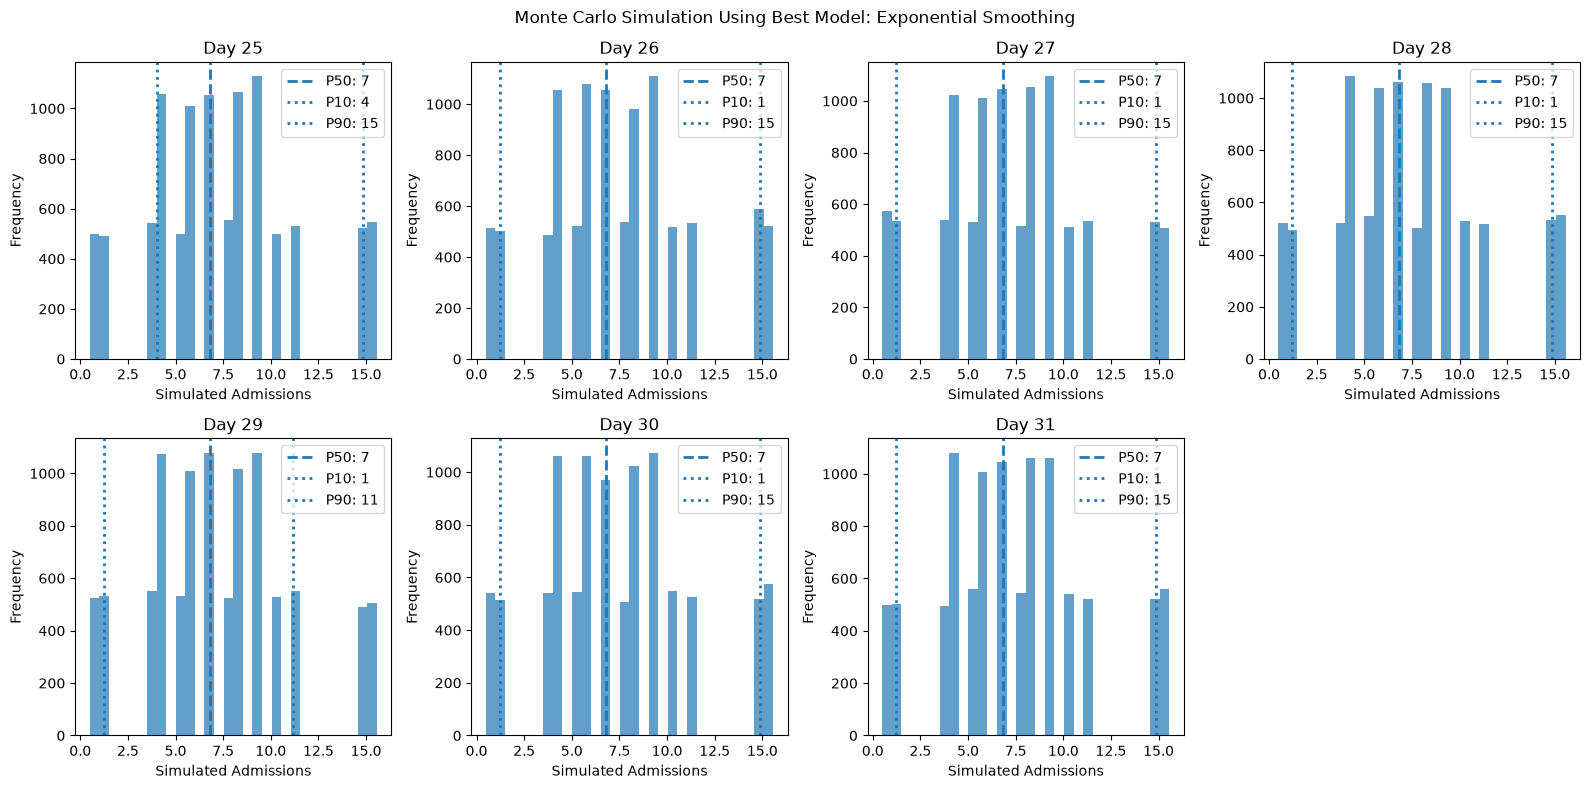

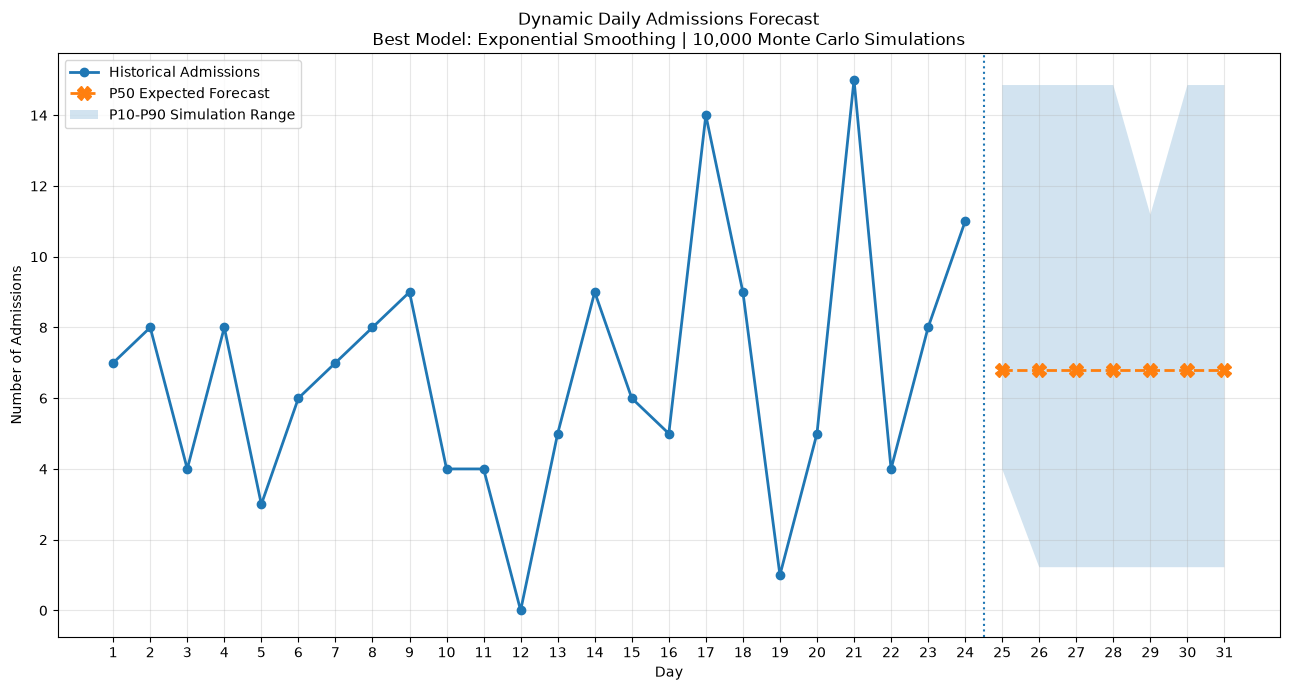

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import (
    SimpleExpSmoothing,
    Holt
)


# ============================================================
# 1. DATA
# ============================================================

df = pd.DataFrame({
    "Day": np.arange(1, 25),

    "Admissions": [
        7, 8, 4, 8, 3, 6,
        7, 8, 9, 4, 4, 0,
        5, 9, 6, 5, 14, 9,
        1, 5, 15, 4, 8, 11
    ]
})

y = df["Admissions"].values.astype(float)


# ============================================================
# 2. FORECASTING MODELS
# ============================================================

# ------------------------------------------------------------
# Model 1: Naive Forecast
# ------------------------------------------------------------

def naive(
    train,
    horizon
):

    return np.repeat(
        train[-1],
        horizon
    )


# ------------------------------------------------------------
# Model 2: Moving Average
# ------------------------------------------------------------

def moving_average(
    train,
    horizon,
    window=3
):

    history = list(train)

    forecasts = []

    for i in range(
        horizon
    ):

        forecast = np.mean(
            history[-window:]
        )

        forecasts.append(
            forecast
        )

        # Recursive forecasting
        history.append(
            forecast
        )

    return np.array(
        forecasts
    )


# ------------------------------------------------------------
# Model 3: Simple Exponential Smoothing
# ------------------------------------------------------------

def exponential_smoothing(
    train,
    horizon
):

    if len(train) < 2:

        return naive(
            train,
            horizon
        )

    model = SimpleExpSmoothing(
        train,
        initialization_method="estimated"
    )

    fitted = model.fit(
        optimized=True
    )

    return fitted.forecast(
        horizon
    )


# ------------------------------------------------------------
# Model 4: Holt's Linear Trend
# ------------------------------------------------------------

def holt(
    train,
    horizon
):

    if len(train) < 3:

        return naive(
            train,
            horizon
        )

    model = Holt(
        train,
        initialization_method="estimated"
    )

    fitted = model.fit(
        optimized=True
    )

    return fitted.forecast(
        horizon
    )


# ============================================================
# 3. MODEL DICTIONARY
# ============================================================

models = {

    "Naive":
        naive,

    "Moving Average":
        moving_average,

    "Exponential Smoothing":
        exponential_smoothing,

    "Holt":
        holt

}


# ============================================================
# 4. ROLLING-ORIGIN MSE
# ============================================================

def rolling_mse(
    model_function,
    data,
    min_train=5
):

    actual = []

    predicted = []

    errors = []


    # Walk forward through historical data

    for t in range(
        min_train,
        len(data)
    ):

        # Historical data available
        # at time t

        train = data[:t]

        # Actual observed admission

        test = data[t]


        try:

            # One-step-ahead forecast

            forecast = model_function(
                train,
                1
            )[0]


            actual.append(
                test
            )

            predicted.append(
                forecast
            )

            errors.append(

                test
                - forecast

            )


        except Exception:

            continue


    # If model cannot generate
    # predictions

    if len(actual) == 0:

        return {

            "MSE": np.inf,

            "RMSE": np.inf,

            "Errors": np.array([])

        }


    # Mean Squared Error

    mse = mean_squared_error(

        actual,

        predicted

    )


    return {

        "MSE":
            mse,

        "RMSE":
            np.sqrt(mse),

        "Errors":
            np.array(errors)

    }


# ============================================================
# 5. MODEL SELECTION
# ============================================================

model_results = []

validation_errors = {}


for name, model in models.items():

    result = rolling_mse(

        model,

        y

    )


    # Save validation errors

    validation_errors[name] = (

        result["Errors"]

    )


    model_results.append({

        "Model":
            name,

        "MSE":
            result["MSE"],

        "RMSE":
            result["RMSE"]

    })


# Convert to DataFrame

results = pd.DataFrame(

    model_results

)


# Sort by lowest MSE

results = results.sort_values(

    "MSE"

).reset_index(

    drop=True

)


# ============================================================
# 6. SELECT BEST MODEL
# ============================================================

best_model_name = (

    results

    .iloc[0]

    ["Model"]

)


best_model = models[

    best_model_name

]


print(

    "\nMODEL COMPARISON"

)

print(

    "=" * 60

)


print(

    results.to_string(

        index=False

    )

)


print(

    "\nBEST MODEL:",

    best_model_name

)


# ============================================================
# 7. BASE FORECAST
# ============================================================

forecast_horizon = 7


base_forecast = best_model(

    y,

    forecast_horizon

)


# Admissions cannot be negative

base_forecast = np.maximum(

    base_forecast,

    0

)


future_days = np.arange(

    25,

    32

)


print(

    "\nBASE FORECAST"

)

print(

    "=" * 60

)


for day, forecast in zip(

    future_days,

    base_forecast

):

    print(

        f"Day {day}: "

        f"{forecast:.2f} admissions"

    )


# ============================================================
# 8. ESTIMATE HISTORICAL FORECAST ERRORS
# ============================================================

errors = validation_errors[

    best_model_name

]


print(

    "\nHISTORICAL FORECAST ERRORS"

)

print(

    "=" * 60

)


print(

    errors

)


print(

    "\nMean Error:",

    np.mean(errors)

)


print(

    "Error Std:",

    np.std(

        errors,

        ddof=1

    )

)


# ============================================================
# 9. MONTE CARLO SIMULATION
# ============================================================

np.random.seed(

    42

)


n_simulations = 10_000


simulated_forecasts = np.zeros(

    (

        n_simulations,

        forecast_horizon

    )

)


for simulation in range(

    n_simulations

):


    # Randomly sample historical
    # forecast errors

    sampled_errors = np.random.choice(

        errors,

        size=forecast_horizon,

        replace=True

    )


    # Base Forecast
    # +
    # Random Forecast Error

    simulated_forecasts[

        simulation

    ] = (

        base_forecast

        + sampled_errors

    )


# Admissions cannot be negative

simulated_forecasts = np.maximum(

    simulated_forecasts,

    0

)


# ============================================================
# 10. FORECAST DISTRIBUTION
# ============================================================

p10 = np.percentile(

    simulated_forecasts,

    10,

    axis=0

)


p50 = np.percentile(

    simulated_forecasts,

    50,

    axis=0

)


p90 = np.percentile(

    simulated_forecasts,

    90,

    axis=0

)


# ============================================================
# 11. FINAL FORECAST TABLE
# ============================================================

forecast_results = pd.DataFrame({

    "Day":

        future_days,


    "Base Forecast":

        np.round(

            base_forecast,

            2

        ),


    "P10 Low":

        np.round(

            p10,

            2

        ),


    "P50 Expected":

        np.round(

            p50,

            2

        ),


    "P90 High":

        np.round(

            p90,

            2

        )

})


print(

    "\nSIMULATED FORECAST"

)

print(

    "=" * 70

)


print(

    forecast_results.to_string(

        index=False

    )

)


# ============================================================
# 12. PLOT SIMULATED DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(

    2,

    4,

    figsize=(16, 8)

)


axes = axes.flatten()


for i in range(

    forecast_horizon

):


    # Histogram

    axes[i].hist(

        simulated_forecasts[:, i],

        bins=30,

        alpha=0.7

    )


    # P50

    axes[i].axvline(

        p50[i],

        linestyle="--",

        linewidth=2,

        label=(

            f"P50: "

            f"{p50[i]:.0f}"

        )

    )


    # P10

    axes[i].axvline(

        p10[i],

        linestyle=":",

        linewidth=2,

        label=(

            f"P10: "

            f"{p10[i]:.0f}"

        )

    )


    # P90

    axes[i].axvline(

        p90[i],

        linestyle=":",

        linewidth=2,

        label=(

            f"P90: "

            f"{p90[i]:.0f}"

        )

    )


    axes[i].set_title(

        f"Day {future_days[i]}"

    )


    axes[i].set_xlabel(

        "Simulated Admissions"

    )


    axes[i].set_ylabel(

        "Frequency"

    )


    axes[i].legend()


# Hide unused subplot

axes[-1].axis(

    "off"

)


plt.suptitle(

    f"Monte Carlo Simulation "

    f"Using Best Model: "

    f"{best_model_name}"

)


plt.tight_layout()

plt.show()


# ============================================================
# 13. HISTORICAL + FORECAST PLOT
# ============================================================

plt.figure(

    figsize=(13, 7)

)


historical_x = np.arange(

    len(y)

)


future_x = np.arange(

    len(y),

    len(y)

    + forecast_horizon

)


# ------------------------------------------------------------
# Historical Admissions
# ------------------------------------------------------------

plt.plot(

    historical_x,

    y,

    marker="o",

    linewidth=2,

    label="Historical Admissions"

)


# ------------------------------------------------------------
# P50 Expected Forecast
# ------------------------------------------------------------

plt.plot(

    future_x,

    p50,

    marker="X",

    markersize=10,

    linestyle="--",

    linewidth=2,

    label="P50 Expected Forecast"

)


# ------------------------------------------------------------
# P10-P90 Simulation Range
# ------------------------------------------------------------

plt.fill_between(

    future_x,

    p10,

    p90,

    alpha=0.2,

    label="P10-P90 Simulation Range"

)


# ------------------------------------------------------------
# Forecast Boundary
# ------------------------------------------------------------

plt.axvline(

    len(y) - 0.5,

    linestyle=":",

    linewidth=1.5

)


# ------------------------------------------------------------
# X-Axis Labels
# ------------------------------------------------------------

all_days = np.arange(

    1,

    32

)


plt.xticks(

    all_days - 1,

    all_days

)


# ------------------------------------------------------------
# Title
# ------------------------------------------------------------

plt.title(

    "Dynamic Daily Admissions Forecast\n"

    f"Best Model: {best_model_name} | "

    "10,000 Monte Carlo Simulations"

)


plt.xlabel(

    "Day"

)


plt.ylabel(

    "Number of Admissions"

)


plt.legend()


plt.grid(

    True,

    alpha=0.3

)


plt.tight_layout()


plt.show()


MODEL COMPARISON
               Model       MSE     RMSE
7-Day Seasonal Naive 13.882353 3.725903
          Holt Trend 19.516156 4.417709
3-Day Moving Average 21.169935 4.601080
               Naive 30.941176 5.562479

BEST MODEL: 7-Day Seasonal Naive

BASE FORECAST
Day 25: 9.00
Day 26: 1.00
Day 27: 5.00
Day 28: 15.00
Day 29: 4.00
Day 30: 8.00
Day 31: 11.00

FORECAST ERRORS
[ 1.  1.  0. -4. -3. -1.  2. -2. -4. 10.  5.  1.  0.  6. -2.  3. -3.]

Mean Error: 0.5882352941176471
Error Std: 3.7924072752246

FINAL SIMULATED FORECAST
 Day  Base Forecast  P10 Low  P50 Expected  P90 High
  25            9.0      5.0           9.0      15.0
  26            1.0      0.0           1.0       7.0
  27            5.0      1.0           5.0      11.0
  28           15.0     11.0          15.0      21.0
  29            4.0      0.0           4.0      10.0
  30            8.0      4.0           8.0      14.0
  31           11.0      7.0          11.0      17.0


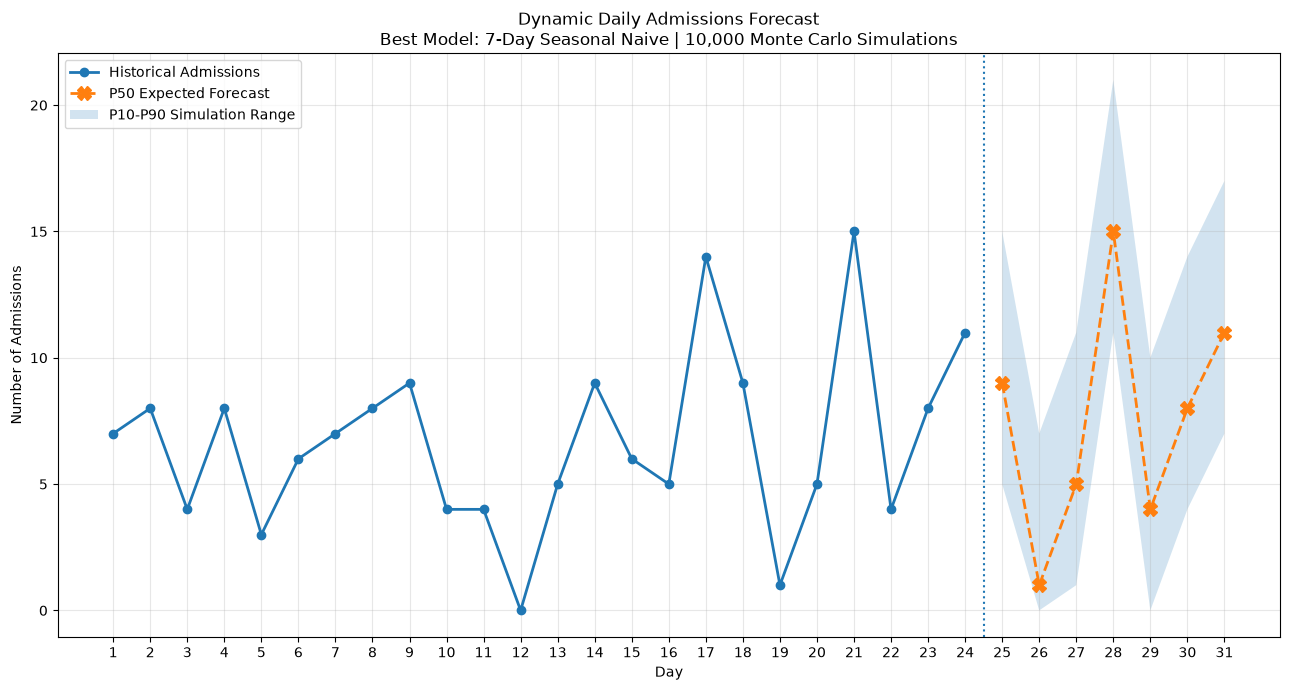

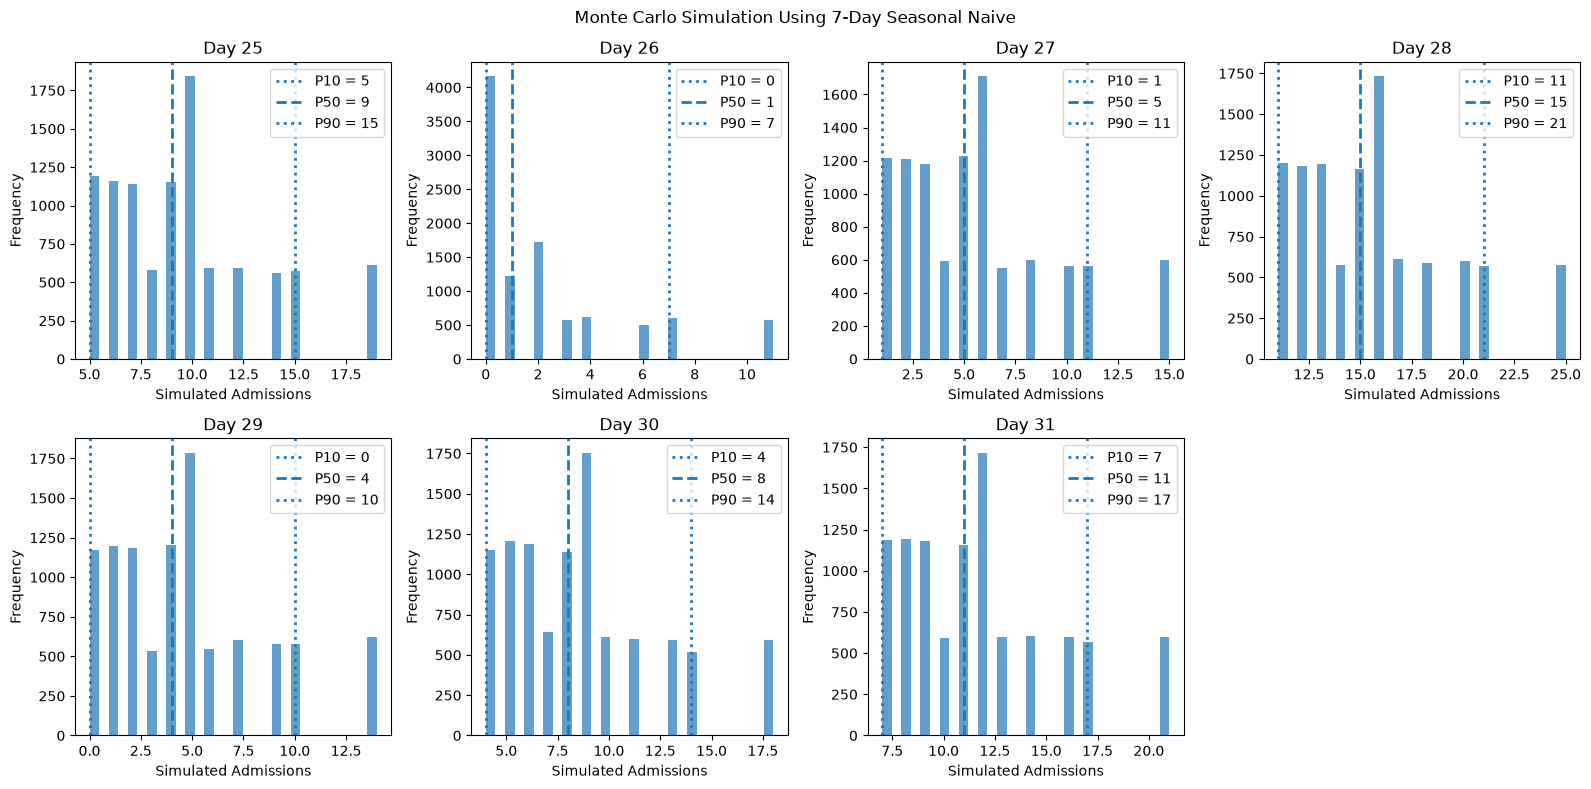

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import Holt


# ============================================================
# 1. HISTORICAL ADMISSIONS DATA
# ============================================================

df = pd.DataFrame({

    "Day": np.arange(1, 25),

    "Admissions": [
        7, 8, 4, 8, 3, 6,
        7, 8, 9, 4, 4, 0,
        5, 9, 6, 5, 14, 9,
        1, 5, 15, 4, 8, 11
    ]

})

y = df["Admissions"].values.astype(float)


# ============================================================
# 2. FORECASTING MODELS
# ============================================================


# ------------------------------------------------------------
# MODEL 1: NAIVE
# Forecast = Last observed value
# ------------------------------------------------------------

def naive(
    train,
    horizon
):

    return np.repeat(

        train[-1],

        horizon

    )


# ------------------------------------------------------------
# MODEL 2: MOVING AVERAGE
# ------------------------------------------------------------

def moving_average(

    train,

    horizon,

    window=3

):

    history = list(train)

    forecasts = []


    for _ in range(

        horizon

    ):

        forecast = np.mean(

            history[-window:]

        )

        forecasts.append(

            forecast

        )

        # Recursive forecast

        history.append(

            forecast

        )


    return np.array(

        forecasts

    )


# ------------------------------------------------------------
# MODEL 3: HOLT LINEAR TREND
# ------------------------------------------------------------

def holt(

    train,

    horizon

):

    if len(train) < 3:

        return naive(

            train,

            horizon

        )


    model = Holt(

        train,

        initialization_method="estimated"

    )


    fitted = model.fit(

        optimized=True

    )


    return fitted.forecast(

        horizon

    )


# ------------------------------------------------------------
# MODEL 4: 7-DAY SEASONAL NAIVE
#
# Forecast Day t+7 = Day t
# ------------------------------------------------------------

def seasonal_naive_7(

    train,

    horizon,

    season_length=7

):

    # If insufficient data,
    # fall back to Naive

    if len(train) < season_length:

        return naive(

            train,

            horizon

        )


    forecasts = []


    for i in range(

        horizon

    ):

        # Use value from
        # same position last week

        index = (

            len(train)

            - season_length

            + i

        )


        if index < len(train):

            forecast = train[

                index

            ]

        else:

            # Recursive seasonal forecast

            forecast = forecasts[

                i - season_length

            ]


        forecasts.append(

            forecast

        )


    return np.array(

        forecasts

    )


# ============================================================
# 3. MODEL DICTIONARY
# ============================================================

models = {

    "Naive":
        naive,

    "3-Day Moving Average":
        moving_average,

    "Holt Trend":
        holt,

    "7-Day Seasonal Naive":
        seasonal_naive_7

}


# ============================================================
# 4. ROLLING-ORIGIN VALIDATION
# ============================================================

def rolling_validation(

    model_function,

    data,

    min_train=7

):

    actual = []

    predicted = []

    errors = []


    # Walk-forward validation

    for t in range(

        min_train,

        len(data)

    ):

        # Data available
        # before prediction

        train = data[

            :t

        ]


        # Actual observation

        test = data[

            t

        ]


        try:

            # One-step ahead forecast

            forecast = model_function(

                train,

                1

            )[0]


            actual.append(

                test

            )


            predicted.append(

                forecast

            )


            errors.append(

                test

                - forecast

            )


        except Exception:

            continue


    # Calculate MSE

    mse = mean_squared_error(

        actual,

        predicted

    )


    return {

        "MSE":

            mse,


        "RMSE":

            np.sqrt(

                mse

            ),


        "Errors":

            np.array(

                errors

            )

    }


# ============================================================
# 5. MODEL SELECTION
# ============================================================

model_results = []

validation_errors = {}


for name, model in models.items():


    result = rolling_validation(

        model,

        y

    )


    # Store errors

    validation_errors[

        name

    ] = result[

        "Errors"

    ]


    # Store model performance

    model_results.append({

        "Model":

            name,


        "MSE":

            result[

                "MSE"

            ],


        "RMSE":

            result[

                "RMSE"

            ]

    })


# Convert results to DataFrame

results = pd.DataFrame(

    model_results

)


# Sort by lowest MSE

results = results.sort_values(

    "MSE"

).reset_index(

    drop=True

)


# ============================================================
# 6. SELECT BEST MODEL
# ============================================================

best_model_name = (

    results

    .iloc[0]

    ["Model"]

)


best_model = models[

    best_model_name

]


print(

    "\nMODEL COMPARISON"

)

print(

    "=" * 60

)


print(

    results.to_string(

        index=False

    )

)


print(

    "\nBEST MODEL:",

    best_model_name

)


# ============================================================
# 7. GENERATE BASE FORECAST
# ============================================================

forecast_horizon = 7


base_forecast = best_model(

    y,

    forecast_horizon

)


# Admissions cannot be negative

base_forecast = np.maximum(

    base_forecast,

    0

)


future_days = np.arange(

    25,

    32

)


print(

    "\nBASE FORECAST"

)

print(

    "=" * 60

)


for day, forecast in zip(

    future_days,

    base_forecast

):

    print(

        f"Day {day}: "

        f"{forecast:.2f}"

    )


# ============================================================
# 8. ESTIMATE HISTORICAL FORECAST ERRORS
# ============================================================

errors = validation_errors[

    best_model_name

]


print(

    "\nFORECAST ERRORS"

)

print(

    "=" * 60

)


print(

    errors

)


print(

    "\nMean Error:",

    np.mean(

        errors

    )

)


print(

    "Error Std:",

    np.std(

        errors,

        ddof=1

    )

)


# ============================================================
# 9. MONTE CARLO SIMULATION
# ============================================================

np.random.seed(

    42

)


n_simulations = 10_000


simulated_forecasts = np.zeros(

    (

        n_simulations,

        forecast_horizon

    )

)


for simulation in range(

    n_simulations

):


    # Randomly sample historical
    # forecast errors

    sampled_errors = np.random.choice(

        errors,

        size=forecast_horizon,

        replace=True

    )


    # Base Forecast
    # +
    # Random Forecast Error

    simulated_forecasts[

        simulation

    ] = (

        base_forecast

        + sampled_errors

    )


# No negative admissions

simulated_forecasts = np.maximum(

    simulated_forecasts,

    0

)


# ============================================================
# 10. P10 / P50 / P90
# ============================================================

p10 = np.percentile(

    simulated_forecasts,

    10,

    axis=0

)


p50 = np.percentile(

    simulated_forecasts,

    50,

    axis=0

)


p90 = np.percentile(

    simulated_forecasts,

    90,

    axis=0

)


# ============================================================
# 11. FINAL FORECAST TABLE
# ============================================================

forecast_results = pd.DataFrame({

    "Day":

        future_days,


    "Base Forecast":

        np.round(

            base_forecast,

            2

        ),


    "P10 Low":

        np.round(

            p10,

            2

        ),


    "P50 Expected":

        np.round(

            p50,

            2

        ),


    "P90 High":

        np.round(

            p90,

            2

        )

})


print(

    "\nFINAL SIMULATED FORECAST"

)

print(

    "=" * 75

)


print(

    forecast_results.to_string(

        index=False

    )

)


# ============================================================
# 12. HISTORICAL + FORECAST PLOT
# ============================================================

plt.figure(

    figsize=(13, 7)

)


# Historical

plt.plot(

    df["Day"],

    y,

    marker="o",

    linewidth=2,

    label="Historical Admissions"

)


# Expected forecast

plt.plot(

    future_days,

    p50,

    marker="X",

    markersize=10,

    linestyle="--",

    linewidth=2,

    label="P50 Expected Forecast"

)


# Uncertainty interval

plt.fill_between(

    future_days,

    p10,

    p90,

    alpha=0.2,

    label="P10-P90 Simulation Range"

)


# Forecast boundary

plt.axvline(

    x=24.5,

    linestyle=":",

    linewidth=1.5

)


# X-axis

plt.xticks(

    np.arange(

        1,

        32

    )

)


plt.title(

    "Dynamic Daily Admissions Forecast\n"

    f"Best Model: {best_model_name} | "

    "10,000 Monte Carlo Simulations"

)


plt.xlabel(

    "Day"

)


plt.ylabel(

    "Number of Admissions"

)


plt.legend()


plt.grid(

    True,

    alpha=0.3

)


plt.tight_layout()


plt.show()


# ============================================================
# 13. SIMULATION DISTRIBUTION
# ============================================================

fig, axes = plt.subplots(

    2,

    4,

    figsize=(16, 8)

)


axes = axes.flatten()


for i in range(

    forecast_horizon

):


    axes[i].hist(

        simulated_forecasts[:, i],

        bins=30,

        alpha=0.7

    )


    # P10

    axes[i].axvline(

        p10[i],

        linestyle=":",

        linewidth=2,

        label=(

            f"P10 = "

            f"{p10[i]:.0f}"

        )

    )


    # P50

    axes[i].axvline(

        p50[i],

        linestyle="--",

        linewidth=2,

        label=(

            f"P50 = "

            f"{p50[i]:.0f}"

        )

    )


    # P90

    axes[i].axvline(

        p90[i],

        linestyle=":",

        linewidth=2,

        label=(

            f"P90 = "

            f"{p90[i]:.0f}"

        )

    )


    axes[i].set_title(

        f"Day {future_days[i]}"

    )


    axes[i].set_xlabel(

        "Simulated Admissions"

    )


    axes[i].set_ylabel(

        "Frequency"

    )


    axes[i].legend()


# Hide unused plot

axes[-1].axis(

    "off"

)


plt.suptitle(

    "Monte Carlo Simulation "

    f"Using {best_model_name}"

)


plt.tight_layout()


plt.show()

=== Optimized Holt-Winters Parameters ===
Alpha (Level Smoothing, α):    0.0000
Beta  (Trend Smoothing, β):    0.0000
Gamma (Seasonal Smoothing, γ): 0.0000
Phi   (Trend Damping Rate, φ): 0.9950

=== 7-Day Student Admissions Forecast ===
     Raw Model Output  Final Whole Integer Forecast
Day                                                
25           8.174132                             9
26           2.501753                             3
27           6.496006                             7
28          11.489967                            12
29           7.706192                             8
30           8.948844                             9
31           9.691863                            10


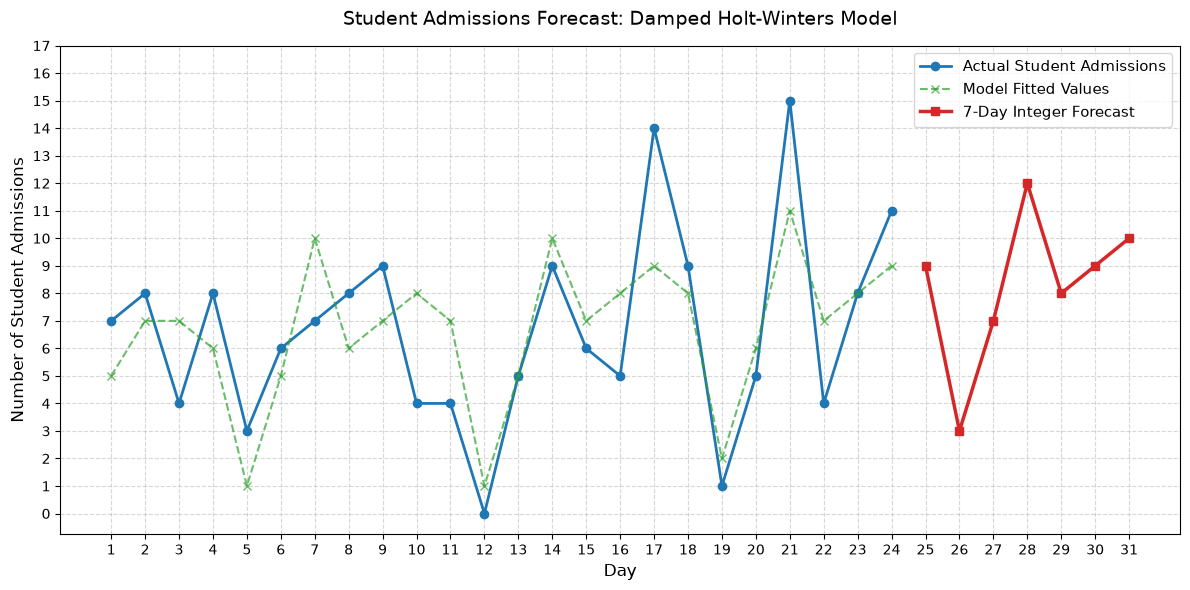

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Historical Student Admissions Data (24 Days)
days = list(range(1, 25))
student_admissions = [
    7, 8, 4, 8, 3, 6, 7, 8, 
    9, 4, 4, 0, 5, 9, 6, 5, 
    14, 9, 1, 5, 15, 4, 8, 11
]

# Create DataFrame
df = pd.DataFrame({'Day': days, 'Admissions': student_admissions}).set_index('Day')

# 2. Fit Holt-Winters Model
# - trend='add': Handles linear changes in student enrollments
# - damped_trend=True: Prevents trend projections from overshooting or dropping excessively
# - seasonal='add', seasonal_periods=7: Captures weekly admission patterns (e.g., lower weekend sign-ups)
model = ExponentialSmoothing(
    df['Admissions'],
    trend='add',
    damped_trend=True,
    seasonal='add',
    seasonal_periods=7,
    initialization_method="estimated"
)
fit_model = model.fit()

# 3. Forecast Next 7 Days (Days 25–31)
forecast_steps = 7
raw_forecast = fit_model.forecast(forecast_steps)

# 4. Enforce Integer & Non-Negative Constraints
# Sets a minimum floor of 0 admissions (change MIN_ADMISSIONS to 1 if 0 isn't allowed)
MIN_ADMISSIONS = 0 

constrained_forecast = np.maximum(MIN_ADMISSIONS, np.ceil(raw_forecast)).astype(int)
fitted_constrained = np.maximum(MIN_ADMISSIONS, np.round(fit_model.fittedvalues)).astype(int)

# 5. Output Optimization Parameters & Forecast Comparison
print("=== Optimized Holt-Winters Parameters ===")
print(f"Alpha (Level Smoothing, α):    {fit_model.params['smoothing_level']:.4f}")
print(f"Beta  (Trend Smoothing, β):    {fit_model.params['smoothing_trend']:.4f}")
print(f"Gamma (Seasonal Smoothing, γ): {fit_model.params['smoothing_seasonal']:.4f}")
print(f"Phi   (Trend Damping Rate, φ): {fit_model.params['damping_trend']:.4f}\n")

print("=== 7-Day Student Admissions Forecast ===")
forecast_df = pd.DataFrame({
    'Day': range(25, 25 + forecast_steps),
    'Raw Model Output': raw_forecast.values,
    'Final Whole Integer Forecast': constrained_forecast.values
}).set_index('Day')

print(forecast_df.to_string())

# 6. Plotting Results
plt.figure(figsize=(12, 6))

# Actual historical student admissions
plt.plot(df.index, df['Admissions'], marker='o', label='Actual Student Admissions', color='#1f77b4', linewidth=2)

# Fitted values on historical data
plt.plot(df.index, fitted_constrained, marker='x', label='Model Fitted Values', color='#2ca02c', linestyle='--', alpha=0.7)

# Forecasted student admissions
forecast_days = list(range(25, 25 + forecast_steps))
plt.plot(forecast_days, constrained_forecast, marker='s', label='7-Day Integer Forecast', color='#d62728', linewidth=2.5)

# Plot formatting
plt.title("Student Admissions Forecast: Damped Holt-Winters Model", fontsize=14, pad=15)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Number of Student Admissions", fontsize=12)
plt.xticks(list(range(1, 25 + forecast_steps)))
plt.yticks(range(0, max(max(student_admissions), max(constrained_forecast)) + 3))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

# Display graph
plt.show()

In [9]:
%pip install xgboost

   ---------------------------------------- 0.0/69.5 MB ? eta -:--:--
   - -------------------------------------- 2.6/69.5 MB 17.6 MB/s eta 0:00:04
   --- ------------------------------------ 6.0/69.5 MB 16.5 MB/s eta 0:00:04
   ----- ---------------------------------- 9.4/69.5 MB 16.5 MB/s eta 0:00:04
   ------- -------------------------------- 12.8/69.5 MB 16.4 MB/s eta 0:00:04
   -------- ------------------------------- 15.5/69.5 MB 15.6 MB/s eta 0:00:04
   ---------- ----------------------------- 18.1/69.5 MB 15.2 MB/s eta 0:00:04
   ------------ --------------------------- 21.0/69.5 MB 14.7 MB/s eta 0:00:04
   ------------- -------------------------- 23.3/69.5 MB 14.3 MB/s eta 0:00:04
   -------------- ------------------------- 25.7/69.5 MB 14.1 MB/s eta 0:00:04
   ---------------- ----------------------- 28.3/69.5 MB 13.8 MB/s eta 0:00:03
   ----------------- ---------------------- 30.1/69.5 MB 13.4 MB/s eta 0:00:03
   ------------------ --------------------- 32.5/69.5 MB 13.3 MB

=== 7-Day XGBoost Admissions Forecast ===
     Raw XGBoost Output  Final Forecast (Ceil Integer)
Day                                                   
25             7.321268                              8
26             2.077993                              3
27             5.908473                              6
28            11.988190                             12
29             5.906166                              6
30             8.713470                              9
31             8.324160                              9


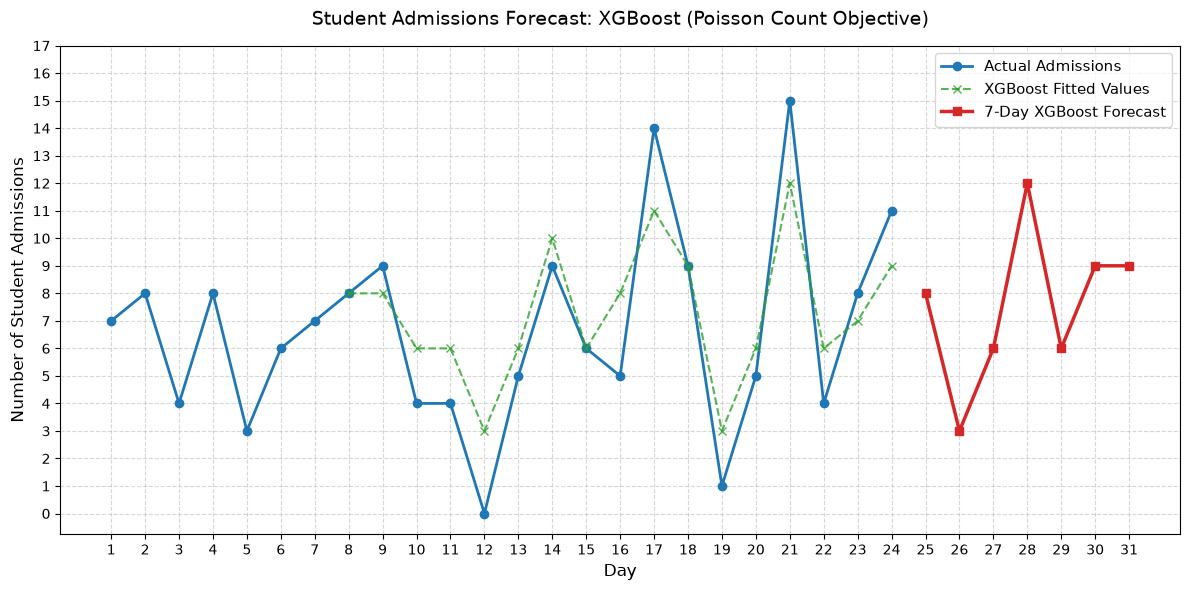

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xgboost as xgb

# 1. Historical Dataset
days = list(range(1, 25))
admissions = [
    7, 8, 4, 8, 3, 6, 7, 8, 
    9, 4, 4, 0, 5, 9, 6, 5, 
    14, 9, 1, 5, 15, 4, 8, 11
]

df = pd.DataFrame({'Day': days, 'Admissions': admissions})

# 2. Feature Engineering Function
def create_features(data):
    df_feat = data.copy()
    df_feat['Day_of_Week'] = (df_feat['Day'] - 1) % 7
    df_feat['Lag_1'] = df_feat['Admissions'].shift(1)
    df_feat['Lag_7'] = df_feat['Admissions'].shift(7)
    df_feat['Rolling_Mean_3'] = df_feat['Admissions'].shift(1).rolling(3).mean()
    return df_feat

# Generate features
df_feat = create_features(df)

# Drop initial NA rows created by lag-7 (Training data will start from Day 8)
train_df = df_feat.dropna().reset_index(drop=True)

feature_cols = ['Day_of_Week', 'Lag_1', 'Lag_7', 'Rolling_Mean_3']
X_train = train_df[feature_cols]
y_train = train_df['Admissions']

# 3. Train XGBoost Model
# 'count:poisson' objective naturally models count data and prevents negative predictions
model = xgb.XGBRegressor(
    objective='count:poisson',
    n_estimators=30,
    max_depth=3,
    learning_rate=0.1,
    random_state=42
)
model.fit(X_train, y_train)

# 4. Recursive Forecasting for Days 25 to 31
history = list(df['Admissions'])
forecasts_raw = []

for step in range(1, 8):
    future_day = 24 + step
    dow = (future_day - 1) % 7
    lag_1 = history[-1]
    lag_7 = history[-7]
    roll_3 = np.mean(history[-3:])
    
    # Build single-row feature set for next day
    X_next = pd.DataFrame([{
        'Day_of_Week': dow,
        'Lag_1': lag_1,
        'Lag_7': lag_7,
        'Rolling_Mean_3': roll_3
    }])
    
    # Predict
    pred = model.predict(X_next)[0]
    forecasts_raw.append(pred)
    history.append(pred)  # Feed predicted value back into history for future lags

# 5. Apply Ceiling Constraint (Round UP to next integer)
constrained_forecast = np.ceil(forecasts_raw).astype(int)

# In-sample fitted values for history (Days 8 to 24)
in_sample_preds = model.predict(X_train)
fitted_values = np.ceil(in_sample_preds).astype(int)

# 6. Display Comparison Table
forecast_df = pd.DataFrame({
    'Day': range(25, 32),
    'Raw XGBoost Output': forecasts_raw,
    'Final Forecast (Ceil Integer)': constrained_forecast
}).set_index('Day')

print("=== 7-Day XGBoost Admissions Forecast ===")
print(forecast_df.to_string())

# 7. Plotting Results
plt.figure(figsize=(12, 6))

# Actual values
plt.plot(df['Day'], df['Admissions'], marker='o', label='Actual Admissions', color='#1f77b4', linewidth=2)

# Fitted values on historical training range (Days 8-24)
plt.plot(train_df['Day'], fitted_values, marker='x', label='XGBoost Fitted Values', color='#2ca02c', linestyle='--', alpha=0.8)

# Forecast values (Days 25-31)
forecast_days = list(range(25, 32))
plt.plot(forecast_days, constrained_forecast, marker='s', label='7-Day XGBoost Forecast', color='#d62728', linewidth=2.5)

plt.title("Student Admissions Forecast: XGBoost (Poisson Count Objective)", fontsize=14, pad=15)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Number of Student Admissions", fontsize=12)
plt.xticks(list(range(1, 32)))
plt.yticks(range(0, max(max(admissions), max(constrained_forecast)) + 3))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

=== Poisson GLM 7-Day Forecast ===
     Raw Expected Value  Final Forecast (Ceil Integer)
Day                                                   
25             8.338186                              9
26             1.588226                              2
27             6.352904                              7
28            12.308751                             13
29             7.764889                              8
30             9.317867                             10
31            10.249654                             11


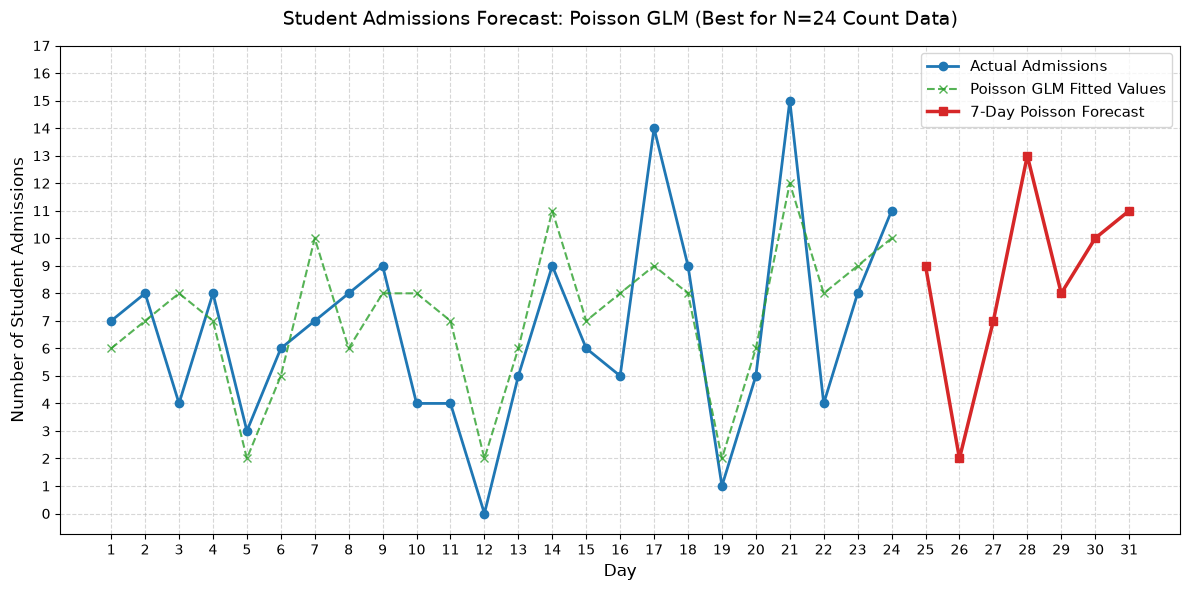

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# 1. Historical Dataset (24 Days)
days = list(range(1, 25))
admissions = [
    7, 8, 4, 8, 3, 6, 7, 8, 
    9, 4, 4, 0, 5, 9, 6, 5, 
    14, 9, 1, 5, 15, 4, 8, 11
]

df = pd.DataFrame({'Day': days, 'Admissions': admissions})
df['Day_of_Week'] = (df['Day'] - 1) % 7  # 0 to 6 categorical day features

# 2. Fit Poisson GLM
# Predicts Admissions using a baseline linear trend ('Day') + day-of-week seasonality
model = smf.glm(
    formula="Admissions ~ Day + C(Day_of_Week)", 
    data=df, 
    family=sm.families.Poisson()
).fit()

# 3. Predict for Next 7 Days (Days 25 to 31)
future_days = pd.DataFrame({
    'Day': range(25, 32),
    'Day_of_Week': [(d - 1) % 7 for d in range(25, 32)]
})

raw_forecast = model.predict(future_days)

# 4. Post-Processing: Ceiling Rounding (Prepare capacity for student admissions)
constrained_forecast = np.ceil(raw_forecast).astype(int)
fitted_values = np.ceil(model.predict(df)).astype(int)

# 5. Output Results
print("=== Poisson GLM 7-Day Forecast ===")
forecast_df = pd.DataFrame({
    'Day': range(25, 32),
    'Raw Expected Value': raw_forecast.values,
    'Final Forecast (Ceil Integer)': constrained_forecast.values
}).set_index('Day')

print(forecast_df.to_string())

# 6. Plotting
plt.figure(figsize=(12, 6))

# Actual admissions
plt.plot(df['Day'], df['Admissions'], marker='o', label='Actual Admissions', color='#1f77b4', linewidth=2)

# GLM In-Sample Fit
plt.plot(df['Day'], fitted_values, marker='x', label='Poisson GLM Fitted Values', color='#2ca02c', linestyle='--', alpha=0.8)

# Future 7-Day Forecast
forecast_days = list(range(25, 32))
plt.plot(forecast_days, constrained_forecast, marker='s', label='7-Day Poisson Forecast', color='#d62728', linewidth=2.5)

plt.title("Student Admissions Forecast: Poisson GLM (Best for N=24 Count Data)", fontsize=14, pad=15)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Number of Student Admissions", fontsize=12)
plt.xticks(list(range(1, 32)))
plt.yticks(range(0, max(max(admissions), max(constrained_forecast)) + 3))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

=== Optimized Damped Holt's Parameters ===
Alpha (Level Smoothing, α):    0.0000
Beta  (Trend Smoothing, β):    0.0000
Phi   (Damping Parameter, φ):  0.9950

=== 7-Day Damped Holt's Forecast ===
     Raw Forecast Value  Final Forecast (Ceil Integer)
Day                                                   
25             7.995829                              8
26             8.097599                              9
27             8.198860                              9
28             8.299615                              9
29             8.399866                              9
30             8.499615                              9
31             8.598866                              9


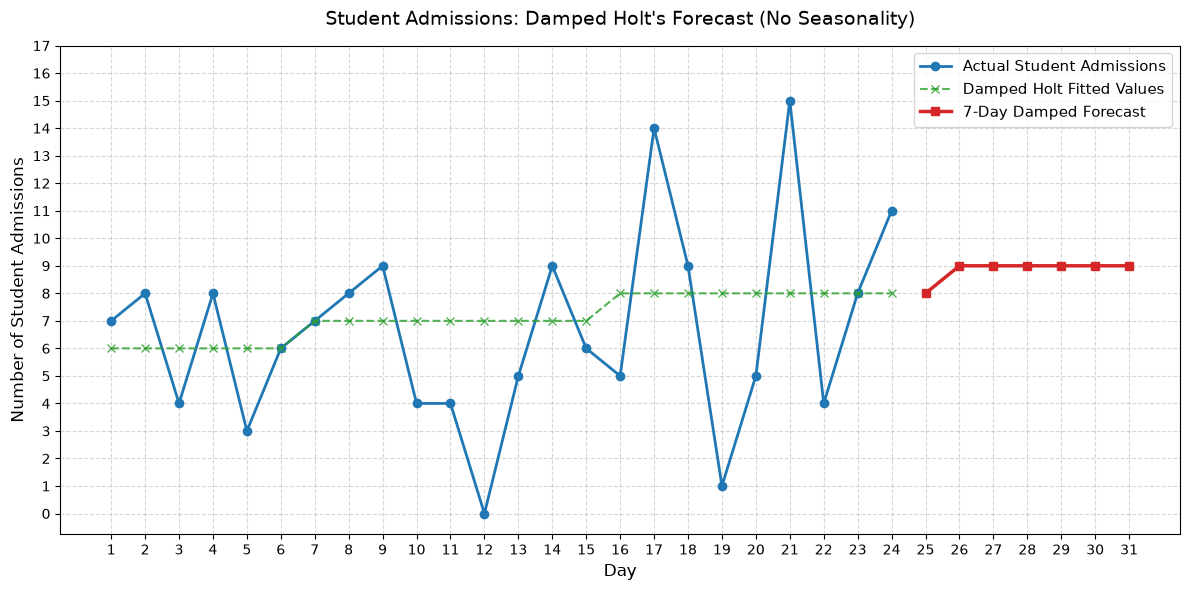

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Dataset Setup (24 Days)
days = list(range(1, 25))
student_admissions = [
    7, 8, 4, 8, 3, 6, 7, 8, 
    9, 4, 4, 0, 5, 9, 6, 5, 
    14, 9, 1, 5, 15, 4, 8, 11
]

df = pd.DataFrame({'Day': days, 'Admissions': student_admissions}).set_index('Day')

# 2. Fit Damped Holt's Model
# - trend='add': Captures overall direction
# - damped_trend=True: Flattens the trend over time (prevents overshooting)
# - seasonal=None: Prevents noisy day-of-week jumps from distorting the forecast
model = ExponentialSmoothing(
    df['Admissions'],
    trend='add',
    damped_trend=True,
    seasonal=None,
    initialization_method="estimated"
)
fit_model = model.fit()

# 3. Forecast Next 7 Days (Days 25 to 31)
forecast_steps = 7
raw_forecast = fit_model.forecast(forecast_steps)

# 4. Post-Processing: Ceiling Rounding (np.ceil) for Student Capacity
constrained_forecast = np.maximum(0, np.ceil(raw_forecast)).astype(int)
fitted_constrained = np.maximum(0, np.ceil(fit_model.fittedvalues)).astype(int)

# 5. Output Optimization Parameters & Forecast
print("=== Optimized Damped Holt's Parameters ===")
print(f"Alpha (Level Smoothing, α):    {fit_model.params['smoothing_level']:.4f}")
print(f"Beta  (Trend Smoothing, β):    {fit_model.params['smoothing_trend']:.4f}")
print(f"Phi   (Damping Parameter, φ):  {fit_model.params['damping_trend']:.4f}\n")

print("=== 7-Day Damped Holt's Forecast ===")
forecast_df = pd.DataFrame({
    'Day': range(25, 25 + forecast_steps),
    'Raw Forecast Value': raw_forecast.values,
    'Final Forecast (Ceil Integer)': constrained_forecast.values
}).set_index('Day')

print(forecast_df.to_string())

# 6. Plotting Results
plt.figure(figsize=(12, 6))

# Historical Actuals
plt.plot(df.index, df['Admissions'], marker='o', label='Actual Student Admissions', color='#1f77b4', linewidth=2)

# Model Fitted Values (In-Sample)
plt.plot(df.index, fitted_constrained, marker='x', label='Damped Holt Fitted Values', color='#2ca02c', linestyle='--', alpha=0.8)

# Future Forecast
forecast_days = list(range(25, 25 + forecast_steps))
plt.plot(forecast_days, constrained_forecast, marker='s', label='7-Day Damped Forecast', color='#d62728', linewidth=2.5)

# Formatting
plt.title("Student Admissions: Damped Holt's Forecast (No Seasonality)", fontsize=14, pad=15)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Number of Student Admissions", fontsize=12)
plt.xticks(list(range(1, 25 + forecast_steps)))
plt.yticks(range(0, max(max(student_admissions), max(constrained_forecast)) + 3))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

=== Optimized Damped Holt-Winters Parameters ===
Alpha (Level Smoothing, α):    0.0000
Beta  (Trend Smoothing, β):    0.0000
Gamma (Seasonal Smoothing, γ): 0.0000
Phi   (Damping Parameter, φ):  0.9950

=== 7-Day Damped Seasonal Forecast ===
     Raw Model Output  Final Forecast (Ceil Integer)
Day                                                 
25           8.174132                              9
26           2.501753                              3
27           6.496006                              7
28          11.489967                             12
29           7.706192                              8
30           8.948844                              9
31           9.691863                             10


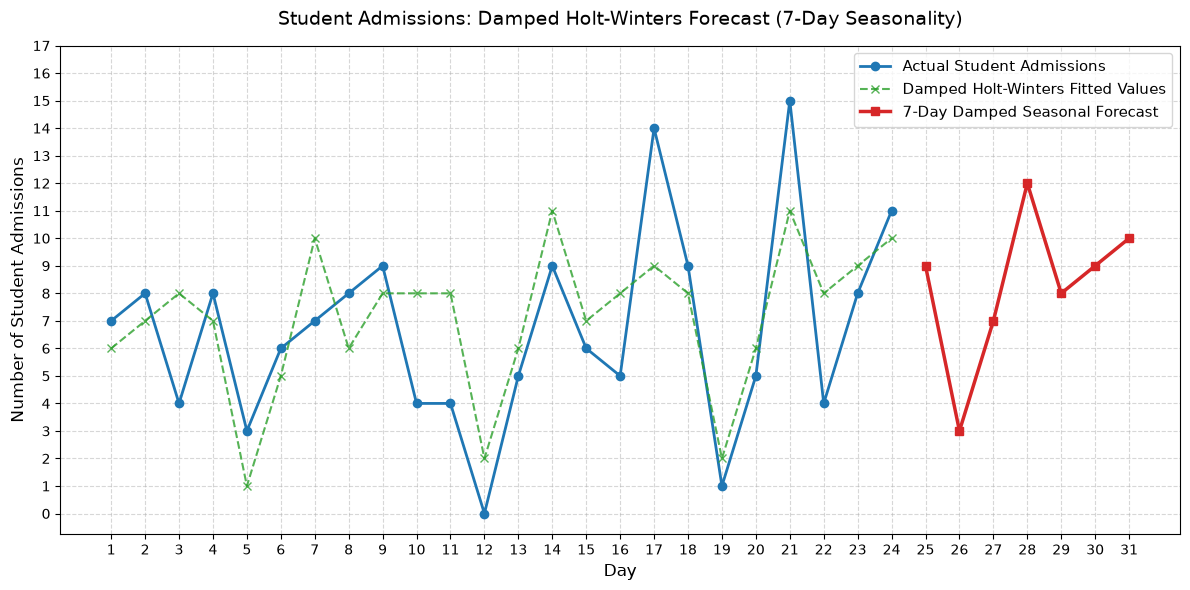

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Historical Dataset (24 Days)
days = list(range(1, 25))
student_admissions = [
    7, 8, 4, 8, 3, 6, 7, 8, 
    9, 4, 4, 0, 5, 9, 6, 5, 
    14, 9, 1, 5, 15, 4, 8, 11
]

df = pd.DataFrame({'Day': days, 'Admissions': student_admissions}).set_index('Day')

# 2. Fit Damped Holt-Winters Model (Damped Trend + 7-Day Seasonality)
model = ExponentialSmoothing(
    df['Admissions'],
    trend='add',
    damped_trend=True,
    seasonal='add',
    seasonal_periods=7,
    initialization_method="estimated"
)
fit_model = model.fit()

# 3. Forecast Next 7 Days (Days 25 to 31)
forecast_steps = 7
raw_forecast = fit_model.forecast(forecast_steps)

# 4. Apply Ceiling Rounding (np.ceil) for Non-Negative Integer Counts
constrained_forecast = np.maximum(0, np.ceil(raw_forecast)).astype(int)
fitted_constrained = np.maximum(0, np.ceil(fit_model.fittedvalues)).astype(int)

# 5. Output Optimization Parameters & Forecast Table
print("=== Optimized Damped Holt-Winters Parameters ===")
print(f"Alpha (Level Smoothing, α):    {fit_model.params['smoothing_level']:.4f}")
print(f"Beta  (Trend Smoothing, β):    {fit_model.params['smoothing_trend']:.4f}")
print(f"Gamma (Seasonal Smoothing, γ): {fit_model.params['smoothing_seasonal']:.4f}")
print(f"Phi   (Damping Parameter, φ):  {fit_model.params['damping_trend']:.4f}\n")

print("=== 7-Day Damped Seasonal Forecast ===")
forecast_df = pd.DataFrame({
    'Day': range(25, 25 + forecast_steps),
    'Raw Model Output': raw_forecast.values,
    'Final Forecast (Ceil Integer)': constrained_forecast.values
}).set_index('Day')

print(forecast_df.to_string())

# 6. Plotting Results
plt.figure(figsize=(12, 6))

# Actual historical student admissions
plt.plot(df.index, df['Admissions'], marker='o', label='Actual Student Admissions', color='#1f77b4', linewidth=2)

# Fitted values on historical data
plt.plot(df.index, fitted_constrained, marker='x', label='Damped Holt-Winters Fitted Values', color='#2ca02c', linestyle='--', alpha=0.8)

# Future Forecast (Days 25-31)
forecast_days = list(range(25, 25 + forecast_steps))
plt.plot(forecast_days, constrained_forecast, marker='s', label='7-Day Damped Seasonal Forecast', color='#d62728', linewidth=2.5)

# Formatting
plt.title("Student Admissions: Damped Holt-Winters Forecast (7-Day Seasonality)", fontsize=14, pad=15)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Number of Student Admissions", fontsize=12)
plt.xticks(list(range(1, 25 + forecast_steps)))
plt.yticks(range(0, max(max(student_admissions), max(constrained_forecast)) + 3))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

c:\Users\Rajan Shrestha\forecast\.venv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


=== Optimized Multiplicative Holt-Winters Parameters ===
Alpha (Level Smoothing, α):    0.0000
Beta  (Trend Smoothing, β):    0.0000
Gamma (Seasonal Smoothing, γ): 0.0000
Phi   (Damping Parameter, φ):  0.9284

=== 7-Day Multiplicative Seasonal Forecast ===
     Raw Forecast Value  Final Forecast (Ceil Integer)
Day                                                   
25             7.836169                              8
26             1.158348                              2
27             5.833539                              6
28            11.881424                             12
29             6.784457                              7
30             8.243662                              9
31             9.612323                             10


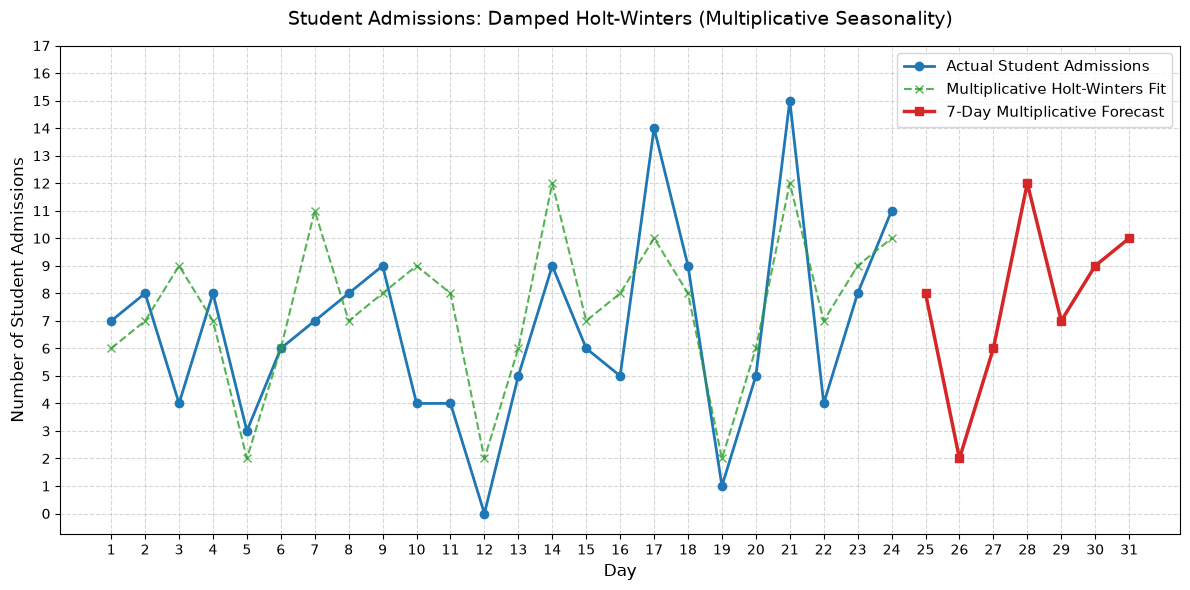

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 1. Historical Dataset (24 Days)
days = list(range(1, 25))
student_admissions = [
    7, 8, 4, 8, 3, 6, 7, 8, 
    9, 4, 4, 0, 5, 9, 6, 5, 
    14, 9, 1, 5, 15, 4, 8, 11
]

df = pd.DataFrame({'Day': days, 'Admissions': student_admissions}).set_index('Day')

# Handle 0 admissions (Day 12) to prevent division-by-zero in multiplicative calculations
admissions_adj = df['Admissions'].replace(0, 0.001)

# 2. Fit Damped Holt-Winters with MULTIPLICATIVE Seasonality
# - trend='add': Additive trend direction
# - damped_trend=True: Prevents trend overshooting
# - seasonal='mul': Multiplicative seasonal variations
model = ExponentialSmoothing(
    admissions_adj,
    trend='add',
    damped_trend=True,
    seasonal='mul',
    seasonal_periods=7,
    initialization_method="estimated"
)
fit_model = model.fit()

# 3. Forecast Next 7 Days (Days 25 to 31)
forecast_steps = 7
raw_forecast = fit_model.forecast(forecast_steps)

# 4. Apply Ceiling Rounding (np.ceil) for Whole Integer Student Capacity
constrained_forecast = np.maximum(0, np.ceil(raw_forecast)).astype(int)
fitted_constrained = np.maximum(0, np.ceil(fit_model.fittedvalues)).astype(int)

# 5. Display Optimized Parameters & Forecast Table
print("=== Optimized Multiplicative Holt-Winters Parameters ===")
print(f"Alpha (Level Smoothing, α):    {fit_model.params['smoothing_level']:.4f}")
print(f"Beta  (Trend Smoothing, β):    {fit_model.params['smoothing_trend']:.4f}")
print(f"Gamma (Seasonal Smoothing, γ): {fit_model.params['smoothing_seasonal']:.4f}")
print(f"Phi   (Damping Parameter, φ):  {fit_model.params['damping_trend']:.4f}\n")

print("=== 7-Day Multiplicative Seasonal Forecast ===")
forecast_df = pd.DataFrame({
    'Day': range(25, 25 + forecast_steps),
    'Raw Forecast Value': raw_forecast.values,
    'Final Forecast (Ceil Integer)': constrained_forecast.values
}).set_index('Day')

print(forecast_df.to_string())

# 6. Plotting Results
plt.figure(figsize=(12, 6))

# Historical actual admissions
plt.plot(df.index, df['Admissions'], marker='o', label='Actual Student Admissions', color='#1f77b4', linewidth=2)

# Multiplicative Fitted Values
plt.plot(df.index, fitted_constrained, marker='x', label='Multiplicative Holt-Winters Fit', color='#2ca02c', linestyle='--', alpha=0.8)

# Multiplicative Forecast Values
forecast_days = list(range(25, 25 + forecast_steps))
plt.plot(forecast_days, constrained_forecast, marker='s', label='7-Day Multiplicative Forecast', color='#d62728', linewidth=2.5)

# Formatting
plt.title("Student Admissions: Damped Holt-Winters (Multiplicative Seasonality)", fontsize=14, pad=15)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Number of Student Admissions", fontsize=12)
plt.xticks(list(range(1, 25 + forecast_steps)))
plt.yticks(range(0, max(max(student_admissions), max(constrained_forecast)) + 3))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

=== Regression Coefficients ===
Intercept              5.250000
C(Day_of_Week)[T.1]    1.163043
C(Day_of_Week)[T.2]    1.826087
C(Day_of_Week)[T.3]    0.793478
C(Day_of_Week)[T.4]   -4.960145
C(Day_of_Week)[T.5]   -1.047101
C(Day_of_Week)[T.6]    3.865942
Day                    0.086957

R-Squared (Fit Quality): 0.5228

=== 7-Day Seasonal OLS Forecast ===
     Raw OLS Output  Final Forecast (Ceil Integer)
Day                                               
25         8.217391                              9
26         2.550725                              3
27         6.550725                              7
28        11.550725                             12
29         7.771739                              8
30         9.021739                             10
31         9.771739                             10


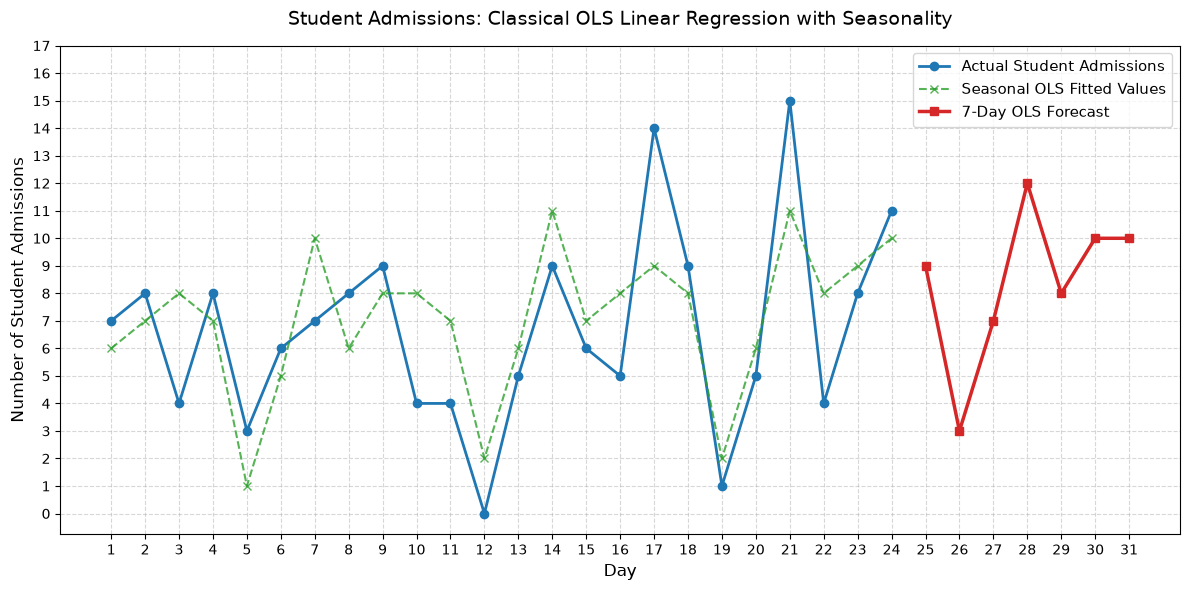

In [17]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

# 1. Historical Dataset (24 Days)
days = list(range(1, 25))
student_admissions = [
    7, 8, 4, 8, 3, 6, 7, 8, 
    9, 4, 4, 0, 5, 9, 6, 5, 
    14, 9, 1, 5, 15, 4, 8, 11
]

df = pd.DataFrame({'Day': days, 'Admissions': student_admissions})
df['Day_of_Week'] = (df['Day'] - 1) % 7  # Day index 0 to 6

# 2. Fit Classical OLS Linear Regression with Trend & Seasonal Dummies
# Formula: Admissions = Intercept + Linear_Trend(Day) + Seasonal_Dummies(Day_of_Week)
model = smf.ols(formula="Admissions ~ Day + C(Day_of_Week)", data=df).fit()

# 3. Forecast Next 7 Days (Days 25 to 31)
future_days = pd.DataFrame({
    'Day': range(25, 32),
    'Day_of_Week': [(d - 1) % 7 for d in range(25, 32)]
})

raw_forecast = model.predict(future_days)

# 4. Post-Processing: Ceiling Rounding (np.ceil) for Student Capacity Planning
constrained_forecast = np.maximum(0, np.ceil(raw_forecast)).astype(int)
fitted_constrained = np.maximum(0, np.ceil(model.predict(df))).astype(int)

# 5. Output Model Regression Summary & 7-Day Forecast
print("=== Regression Coefficients ===")
print(model.params.to_string())
print(f"\nR-Squared (Fit Quality): {model.rsquared:.4f}\n")

print("=== 7-Day Seasonal OLS Forecast ===")
forecast_df = pd.DataFrame({
    'Day': range(25, 32),
    'Raw OLS Output': raw_forecast.values,
    'Final Forecast (Ceil Integer)': constrained_forecast.values
}).set_index('Day')

print(forecast_df.to_string())

# 6. Plotting Results
plt.figure(figsize=(12, 6))

# Actual historical student admissions
plt.plot(df['Day'], df['Admissions'], marker='o', label='Actual Student Admissions', color='#1f77b4', linewidth=2)

# OLS Fitted Values (In-Sample)
plt.plot(df['Day'], fitted_constrained, marker='x', label='Seasonal OLS Fitted Values', color='#2ca02c', linestyle='--', alpha=0.8)

# Future Forecast (Days 25-31)
forecast_days = list(range(25, 32))
plt.plot(forecast_days, constrained_forecast, marker='s', label='7-Day OLS Forecast', color='#d62728', linewidth=2.5)

# Formatting
plt.title("Student Admissions: Classical OLS Linear Regression with Seasonality", fontsize=14, pad=15)
plt.xlabel("Day", fontsize=12)
plt.ylabel("Number of Student Admissions", fontsize=12)
plt.xticks(list(range(1, 32)))
plt.yticks(range(0, max(max(student_admissions), max(constrained_forecast)) + 3))
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.tight_layout()

plt.show()

Fitted parameters:
  smoothing_level: 1.4901161193847656e-08
  smoothing_trend: 2.1533341081880302e-10
  smoothing_seasonal: 0.0
  damping_trend: 0.995
  initial_level: 556.5349430454972
  initial_trend: -12.610627625266288
  initial_seasons: [ 150.83714678 -132.80223601]
  use_boxcox: False
  lamda: None
  remove_bias: False

Forecast:
     Period   Forecast
2025-Autumn 620.845639
2026-Spring 325.091314
2026-Autumn 596.676330
2027-Spring 301.042851


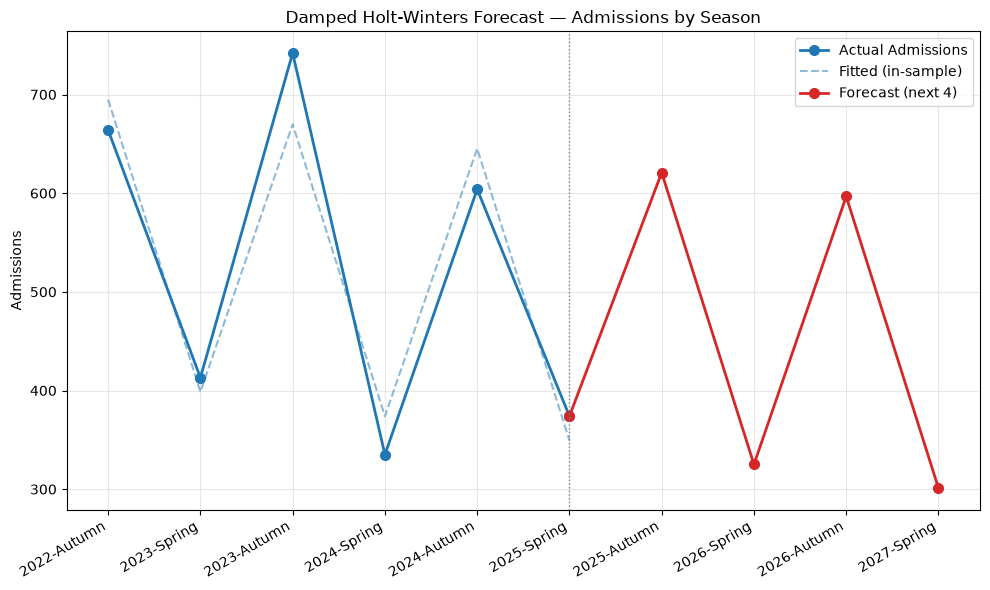

In [4]:
"""
Damped Holt-Winters Forecast for Admissions Data
--------------------------------------------------
Fits an additive-trend, additive-seasonal, damped Holt-Winters model
(seasonal period = 2, i.e. Spring/Autumn) and forecasts the next 4 periods.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# ---------------------------------------------------------
# 1. Data
# ---------------------------------------------------------
history = pd.DataFrame({
    "Period": ["2022-Autumn", "2023-Spring", "2023-Autumn", "2024-Spring", "2024-Autumn", "2025-Spring"],
    "Admissions": [664, 413, 742, 335, 604, 374]
})

y = history["Admissions"]

# ---------------------------------------------------------
# 2. Fit Damped Holt-Winters model
# ---------------------------------------------------------
model = ExponentialSmoothing(
    y,
    trend="add",
    damped_trend=True,
    seasonal="add",
    seasonal_periods=2,          # 2 seasons per cycle: Spring & Autumn
    initialization_method="estimated"
)
fit = model.fit()

print("Fitted parameters:")
for k, v in fit.params.items():
    print(f"  {k}: {v}")

# ---------------------------------------------------------
# 3. Forecast next 4 periods
# ---------------------------------------------------------
n_forecast = 4
forecast = fit.forecast(n_forecast)

future_labels = ["2025-Autumn", "2026-Spring", "2026-Autumn", "2027-Spring"]
forecast_df = pd.DataFrame({
    "Period": future_labels,
    "Forecast": forecast.values
})

print("\nForecast:")
print(forecast_df.to_string(index=False))

# ---------------------------------------------------------
# 4. Plot: history + fitted values + forecast
# ---------------------------------------------------------
all_labels = list(history["Period"]) + future_labels
x_hist = np.arange(len(history))
x_fcst = np.arange(len(history), len(history) + n_forecast)

plt.figure(figsize=(10, 6))

# Actual data
plt.plot(x_hist, y, "o-", color="#1f77b4", label="Actual Admissions", linewidth=2, markersize=7)

# Fitted values (in-sample)
plt.plot(x_hist, fit.fittedvalues, "--", color="#1f77b4", alpha=0.5, label="Fitted (in-sample)")

# Forecast, connected to last actual point
plt.plot(
    np.concatenate([[x_hist[-1]], x_fcst]),
    np.concatenate([[y.iloc[-1]], forecast.values]),
    "o-", color="#d62728", label="Forecast (next 4)", linewidth=2, markersize=7
)

plt.xticks(np.arange(len(all_labels)), all_labels, rotation=30, ha="right")
plt.ylabel("Admissions")
plt.title("Damped Holt-Winters Forecast — Admissions by Season")
plt.axvline(x=x_hist[-1], color="gray", linestyle=":", linewidth=1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("damped_hw_forecast.png", dpi=150)
plt.show()

                 Generalized Linear Model Regression Results                  
Dep. Variable:             Admissions   No. Observations:                    6
Model:                            GLM   Df Residuals:                        3
Model Family:                 Poisson   Df Model:                            2
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -33.005
Date:                Mon, 27 Jul 2026   Deviance:                       17.708
Time:                        10:58:42   Pearson chi2:                     17.8
No. Iterations:                     4   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                          coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept               6.5777    

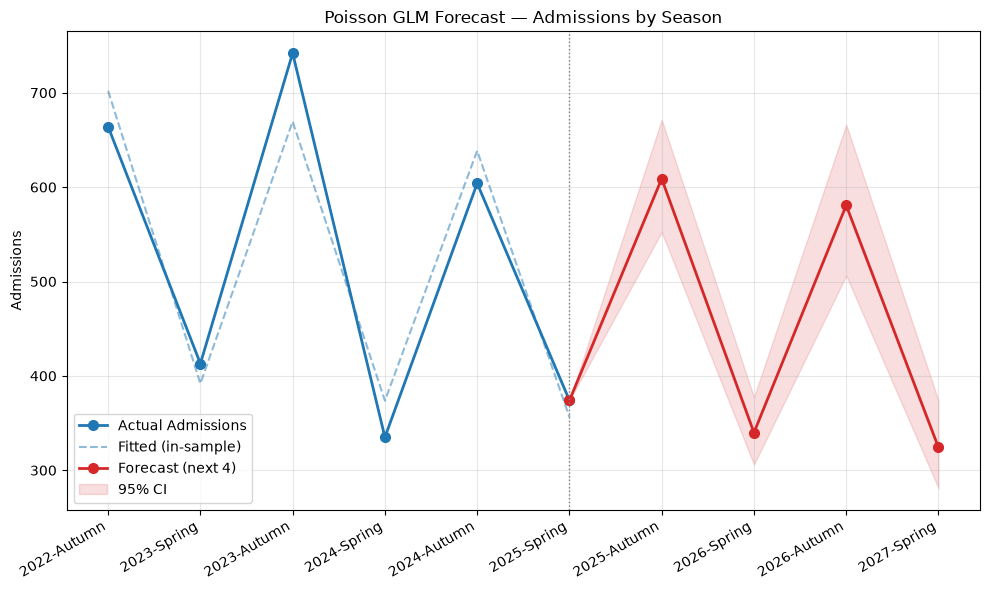

In [5]:
"""
Poisson GLM Forecast for Admissions Data
--------------------------------------------------
Models Admissions ~ trend + Season using a Poisson GLM (log link),
then forecasts the next 4 periods with 95% prediction intervals.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ---------------------------------------------------------
# 1. Data
# ---------------------------------------------------------
history = pd.DataFrame({
    "Period": ["2022-Autumn", "2023-Spring", "2023-Autumn", "2024-Spring", "2024-Autumn", "2025-Spring"],
    "Year": [2022, 2023, 2023, 2024, 2024, 2025],
    "Season": ["Autumn", "Spring", "Autumn", "Spring", "Autumn", "Spring"],
    "Admissions": [664, 413, 742, 335, 604, 374]
})
history["t"] = np.arange(1, len(history) + 1)   # simple time trend index

# ---------------------------------------------------------
# 2. Fit Poisson GLM:  Admissions ~ trend + Season (log link)
# ---------------------------------------------------------
model = smf.glm(
    "Admissions ~ t + C(Season)",
    data=history,
    family=sm.families.Poisson()
)
fit = model.fit()

print(fit.summary())

# Overdispersion check (Pearson chi2 / df). Poisson assumes ~1.
pearson_chi2 = fit.pearson_chi2
dispersion = pearson_chi2 / fit.df_resid
print(f"\nDispersion (Pearson chi2 / df_resid): {dispersion:.2f}")
if dispersion > 1.5:
    print("-> Notable overdispersion: with more data, consider a "
          "quasi-Poisson (scale='X2') or Negative Binomial GLM instead.")

# ---------------------------------------------------------
# 3. Forecast next 4 periods
# ---------------------------------------------------------
future = pd.DataFrame({
    "Period": ["2025-Autumn", "2026-Spring", "2026-Autumn", "2027-Spring"],
    "Season": ["Autumn", "Spring", "Autumn", "Spring"],
    "t": np.arange(len(history) + 1, len(history) + 5)
})

pred = fit.get_prediction(future)
pred_summary = pred.summary_frame(alpha=0.05)  # 95% PI
future["Forecast"] = pred_summary["mean"]
future["CI_lower"] = pred_summary["mean_ci_lower"]
future["CI_upper"] = pred_summary["mean_ci_upper"]

print("\nForecast (mean + 95% CI):")
print(future[["Period", "Forecast", "CI_lower", "CI_upper"]].to_string(index=False))

# ---------------------------------------------------------
# 4. Plot: history + fitted values + forecast with CI band
# ---------------------------------------------------------
history["Fitted"] = fit.fittedvalues

all_labels = list(history["Period"]) + list(future["Period"])
x_hist = np.arange(len(history))
x_fcst = np.arange(len(history), len(history) + len(future))

plt.figure(figsize=(10, 6))

# Actual data
plt.plot(x_hist, history["Admissions"], "o-", color="#1f77b4",
         label="Actual Admissions", linewidth=2, markersize=7)

# Fitted values (in-sample)
plt.plot(x_hist, history["Fitted"], "--", color="#1f77b4", alpha=0.5,
         label="Fitted (in-sample)")

# Forecast, connected to last actual point
x_join = np.concatenate([[x_hist[-1]], x_fcst])
y_join = np.concatenate([[history["Admissions"].iloc[-1]], future["Forecast"].values])
plt.plot(x_join, y_join, "o-", color="#d62728", label="Forecast (next 4)",
         linewidth=2, markersize=7)

# 95% CI band around forecast
ci_lower_join = np.concatenate([[history["Admissions"].iloc[-1]], future["CI_lower"].values])
ci_upper_join = np.concatenate([[history["Admissions"].iloc[-1]], future["CI_upper"].values])
plt.fill_between(x_join, ci_lower_join, ci_upper_join, color="#d62728", alpha=0.15,
                  label="95% CI")

plt.xticks(np.arange(len(all_labels)), all_labels, rotation=30, ha="right")
plt.ylabel("Admissions")
plt.title("Poisson GLM Forecast — Admissions by Season")
plt.axvline(x=x_hist[-1], color="gray", linestyle=":", linewidth=1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("poisson_glm_forecast.png", dpi=150)
plt.show()

c:\Users\Rajan Shrestha\forecast\.venv\Lib\site-packages\statsmodels\stats\stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


                            OLS Regression Results                            
Dep. Variable:             Admissions   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.882
Method:                 Least Squares   F-statistic:                     19.75
Date:                Mon, 27 Jul 2026   Prob (F-statistic):             0.0188
Time:                        11:05:07   Log-Likelihood:                -30.819
No. Observations:                   6   AIC:                             67.64
Df Residuals:                       3   BIC:                             67.01
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
Intercept             707.1250    

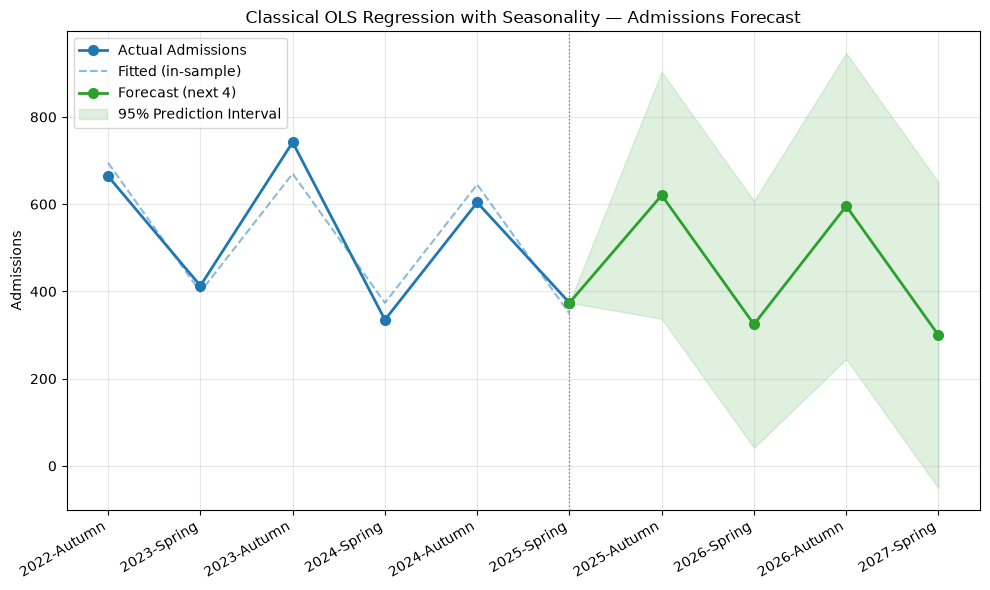

In [6]:
"""
Classical OLS Linear Regression with Seasonality — Admissions Forecast
------------------------------------------------------------------------
Models Admissions ~ trend + Season using ordinary least squares,
then forecasts the next 4 periods with 95% prediction intervals.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

# ---------------------------------------------------------
# 1. Data
# ---------------------------------------------------------
history = pd.DataFrame({
    "Period": ["2022-Autumn", "2023-Spring", "2023-Autumn", "2024-Spring", "2024-Autumn", "2025-Spring"],
    "Year": [2022, 2023, 2023, 2024, 2024, 2025],
    "Season": ["Autumn", "Spring", "Autumn", "Spring", "Autumn", "Spring"],
    "Admissions": [664, 413, 742, 335, 604, 374]
})
history["t"] = np.arange(1, len(history) + 1)   # simple time trend index

# ---------------------------------------------------------
# 2. Fit OLS:  Admissions ~ trend + Season
# ---------------------------------------------------------
model = smf.ols("Admissions ~ t + C(Season)", data=history)
fit = model.fit()

print(fit.summary())
print(f"\nR-squared: {fit.rsquared:.3f}")

# ---------------------------------------------------------
# 3. Forecast next 4 periods (with 95% prediction interval)
# ---------------------------------------------------------
future = pd.DataFrame({
    "Period": ["2025-Autumn", "2026-Spring", "2026-Autumn", "2027-Spring"],
    "Season": ["Autumn", "Spring", "Autumn", "Spring"],
    "t": np.arange(len(history) + 1, len(history) + 5)
})

pred = fit.get_prediction(future)
pred_summary = pred.summary_frame(alpha=0.05)  # 95% PI (obs_ci) and CI (mean_ci)
future["Forecast"] = pred_summary["mean"]
future["PI_lower"] = pred_summary["obs_ci_lower"]   # prediction interval (individual obs)
future["PI_upper"] = pred_summary["obs_ci_upper"]

print("\nForecast (mean + 95% prediction interval):")
print(future[["Period", "Forecast", "PI_lower", "PI_upper"]].to_string(index=False))

# ---------------------------------------------------------
# 4. Plot: history + fitted values + forecast with PI band
# ---------------------------------------------------------
history["Fitted"] = fit.fittedvalues

all_labels = list(history["Period"]) + list(future["Period"])
x_hist = np.arange(len(history))
x_fcst = np.arange(len(history), len(history) + len(future))

plt.figure(figsize=(10, 6))

# Actual data
plt.plot(x_hist, history["Admissions"], "o-", color="#1f77b4",
         label="Actual Admissions", linewidth=2, markersize=7)

# Fitted values (in-sample)
plt.plot(x_hist, history["Fitted"], "--", color="#1f77b4", alpha=0.5,
         label="Fitted (in-sample)")

# Forecast, connected to last actual point
x_join = np.concatenate([[x_hist[-1]], x_fcst])
y_join = np.concatenate([[history["Admissions"].iloc[-1]], future["Forecast"].values])
plt.plot(x_join, y_join, "o-", color="#2ca02c", label="Forecast (next 4)",
         linewidth=2, markersize=7)

# 95% prediction interval band around forecast
pi_lower_join = np.concatenate([[history["Admissions"].iloc[-1]], future["PI_lower"].values])
pi_upper_join = np.concatenate([[history["Admissions"].iloc[-1]], future["PI_upper"].values])
plt.fill_between(x_join, pi_lower_join, pi_upper_join, color="#2ca02c", alpha=0.15,
                  label="95% Prediction Interval")

plt.xticks(np.arange(len(all_labels)), all_labels, rotation=30, ha="right")
plt.ylabel("Admissions")
plt.title("Classical OLS Regression with Seasonality — Admissions Forecast")
plt.axvline(x=x_hist[-1], color="gray", linestyle=":", linewidth=1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("ols_seasonal_forecast.png", dpi=150)
plt.show()